<a href="https://colab.research.google.com/github/FernandoMcv/plant-disease-vision-transformers/blob/main/notebooks/vision_transformers_finetuning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import cv2
import matplotlib.pyplot as plt
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu

# 1. Carga una imagen de prueba de tu Google Drive
ruta_imagen = "/content/drive/MyDrive/DatasetCOLEAF/train/manganese-Mn/Mn (83).jpg"
imagen_rgb = cv2.cvtColor(cv2.imread(ruta_imagen), cv2.COLOR_BGR2RGB)

# 2. Convierte a escala de grises y calcula la magia: el umbral de Otsu
gris = rgb2gray(imagen_rgb)
umbral = threshold_otsu(gris)

# 3. Crea la silueta (mascara binaria)
# En CoLeaf el fondo es claro y la hoja oscura, por eso usamos "menor que" (<)
silueta = gris < umbral

# 4. Graficamos el antes y el después
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(imagen_rgb)
ax[0].set_title("Imagen Original")
ax[1].imshow(silueta, cmap='gray')
ax[1].set_title(f"Silueta de Otsu (Corte matemático: {umbral:.2f})")
plt.show()

In [ ]:
import os
import cv2
import numpy as np
from skimage.measure import label, regionprops
from skimage.color import rgb2gray
from skimage.filters import threshold_otsu
import matplotlib.pyplot as plt

def crop_leaf_with_regionprops(input_path, output_path):
    # 1. Leer la imagen
    image = cv2.imread(input_path)
    if image is None:
        return
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # 2. Convertir a escala de grises para encontrar el contraste
    gray = rgb2gray(image_rgb)

    # 3. Aplicar umbral (Otsu) para separar la hoja del fondo
    # Como el fondo de CoLeaf es claro y la hoja oscura, invertimos la lógica
    thresh = threshold_otsu(gray)
    binary = gray < thresh # La hoja será True (blanco), el fondo False (negro)

    # 4. Etiquetar las regiones encontradas
    label_img = label(binary)
    regions = regionprops(label_img)

    if not regions:
        # Failsafe: Si no detecta nada, guarda la original
        cv2.imwrite(output_path, image)
        return

    # 5. Encontrar la región más grande (asumimos que es la hoja, no una manchita de polvo)
    largest_region = max(regions, key=lambda r: r.area)

    # 6. Obtener las coordenadas de la caja delimitadora (Bounding Box)
    min_row, min_col, max_row, max_col = largest_region.bbox

    # 7. Recortar la imagen original usando esas coordenadas
    cropped_image = image[min_row:max_row, min_col:max_col]

    # 8. Guardar la imagen recortada
    cv2.imwrite(output_path, cropped_image)

def process_dataset(original_dir, new_dir):

    for root, dirs, files in os.walk(original_dir):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                # Construir rutas
                input_file_path = os.path.join(root, file)

                # Crear la misma estructura de carpetas en el nuevo directorio
                relative_path = os.path.relpath(root, original_dir)
                output_folder = os.path.join(new_dir, relative_path)
                os.makedirs(output_folder, exist_ok=True)

                output_file_path = os.path.join(output_folder, file)

                # Procesar y recortar
                crop_leaf_with_regionprops(input_file_path, output_file_path)
    print(f" Dataset guardado en: {new_dir}")

RUTA_DATASET_ORIGINAL = "/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido"
RUTA_DATASET_RECORTADO = "/content/si/DatasetCOLEAF_Recortado"



In [ ]:
process_dataset(RUTA_DATASET_ORIGINAL, RUTA_DATASET_RECORTADO)

In [ ]:
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu126

!pip install timm

!pip install pytorch-lightning torchview imageio matplotlib scikit-learn pandas seaborn graphviz transformers scikit-image

Looking in indexes: https://download.pytorch.org/whl/cu126
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 32.9 MB/s eta 0:00:00


In [ ]:
!pip install torch==2.10.0 torchvision==0.25.0 torchaudio==2.10.0 --index-url https://download.pytorch.org/whl/cpu

Looking in indexes: https://download.pytorch.org/whl/cpu


In [ ]:
#Cuando se corren los VIT
# 2. Instalación desde el repositorio de TIMM (para modelos actualizados)
!pip install git+https://github.com/rwightman/pytorch-image-models.git

# 3. Resto de librerías del ecosistema ML y gráficas
!pip install pytorch-lightning torchview imageio matplotlib scikit-learn pandas seaborn graphviz transformers scikit-image

  Cloning https://github.com/rwightman/pytorch-image-models.git to /tmp/pip-req-build-b3ll_rg3
  Running command git clone --filter=blob:none --quiet https://github.com/rwightman/pytorch-image-models.git /tmp/pip-req-build-b3ll_rg3
  Resolved https://github.com/rwightman/pytorch-image-models.git to commit c769a585e0915c58fd7bb92f2355377aab7fc0e0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timm: filename=timm-1.0.27.dev0-py3-none-any.whl size=2569481 sha256=a1f6f36082d736ff7b1be163e9926ba83fcdfa63fdbf74493599f8d2b21c31f4
  Stored in directory: /tmp/pip-ephem-wheel-cache-85aerl6m/wheels/62/3c/74/390e961b002559b53451e6fb321c0865417204fd65d3becc9d
Successfully built timm
  Attempting uninstall: timm
    Found existing installation: timm 1.0.26
    Uninstalling timm-1.0.26:
      Successfully uninstalled timm-1.0.26
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 7.2 MB/

Usos **MAMBA**

In [ ]:
!pip install torch==2.4.0 torchvision==0.19.0 torchaudio==2.4.0 --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 799.0/799.0 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 58.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 68.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 31.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 15.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 46.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 11.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 22.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 11.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196

In [ ]:
!pip install ninja packaging
!pip install causal-conv1d==1.4.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 8.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for causal-conv1d: filename=causal_conv1d-1.4.0-cp312-cp312-linux_x86_64.whl size=104884589 sha256=70c6d91d00c625d750b83c9c4bdd0bd395c61aff9baa8c0d58e0a33dabbe3b4e
  Stored in directory: /root/.cache/pip/wheels/3a/bd/04/a4893fd5ad69a02f55b49f04dc1dbbd7c439332db7895f62ff
Successfully built causal-conv1d


In [ ]:
# 1. Instalaciones críticas de Mamba
!pip install mamba-ssm --no-build-isolation

# 2. Instalación desde el repositorio de TIMM (para modelos actualizados)
!pip install git+https://github.com/rwightman/pytorch-image-models.git

# 3. Resto de librerías del ecosistema ML y gráficas
!pip install pytorch-lightning torchview imageio matplotlib scikit-learn pandas seaborn graphviz transformers scikit-image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.1/121.1 kB 6.4 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.0-cp312-cp312-linux_x86_64.whl size=533244411 sha256=ea759e631ed848a5d403aab5b985febfcfa445b95b158649fdda14f6b6726fe2
  Stored in directory: /root/.cache/pip/wheels/4c/4c/6f/d6add86ebe5c3dbd407ad3b593ecb31cda9adf70801387df4a
Successfully built mamba-ssm
  Cloning https://github.com/rwightman/pytorch-image-models.git to /tmp/pip-req-build-au2itkzq
  Running command git clone --filter=blob:none --quiet https://github.com/rwightman/pytorch-image-models.git /tmp/pip-req-build-au2itkzq
  Resolved https://github.com/rwightman/pytorch-image-models.git to commit 85bb3304d2b518869088d12d38d5e0f1c094d3fd
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for timm: filename=timm-1.0.25-py3-none-any.whl size=2566113 sha2

In [ ]:
# --- 1. LIBRERÍAS ESTÁNDAR ---
import os
import sys
import gc
import json
import shutil
import warnings
import requests
import multiprocessing
from glob import glob
from datetime import datetime

warnings.filterwarnings("ignore")

# --- 2. MANEJO DE DATOS Y VISUALIZACIÓN ---
import numpy as np
import pandas as pd
import seaborn as sn
import matplotlib.pyplot as plt
import imageio
import graphviz
from PIL import Image
from tqdm.notebook import tqdm

# --- 3. MÉTRICAS Y MACHINE LEARNING TRADICIONAL ---
from sklearn import metrics as sk_metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             f1_score, classification_report, accuracy_score)
from skimage.measure import label, regionprops

# --- 4. PYTORCH CORE ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.utils.data.sampler import SubsetRandomSampler
from torch.cuda.amp import GradScaler

# --- 5. TORCHVISION ---
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF
import torchvision.models as models
from torchvision import datasets
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor

# --- 6. PYTORCH LIGHTNING Y ECOSISTEMA ---
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import Callback, EarlyStopping, ModelCheckpoint
from torchmetrics.classification import Accuracy
from torchview import draw_graph
import timm

# --- 7. HUGGING FACE TRANSFORMERS ---
from transformers import (
    ViTImageProcessor,
    ViTForImageClassification,
    BeitImageProcessor,
    BeitForImageClassification
)

# --- VERIFICACIÓN DE ENTORNO COLAB ---
print(f"PyTorch Version: {torch.__version__}")
print(f"GPU Disponible: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Asignada: {torch.cuda.get_device_name(0)}")

PyTorch Version: 2.8.0+cu126
GPU Disponible: True
GPU Asignada: Tesla T4


In [ ]:
import os
import matplotlib.pyplot as plt

def Show_data(DATA_PATH, type):
    # Asegúrate de usar la variable correcta para evitar sobreescribir el DATA_PATH global
    full_path = os.path.join(DATA_PATH, type)
    list_dire_clases= [f.path for f in os.scandir(full_path) if f.is_dir()]
    list_name_clases = [os.path.basename(x) for x in list_dire_clases]

    cantidades = []

    for class_path, class_name in zip(list_dire_clases, list_name_clases):
        # 1. Obtenemos todos los archivos de la carpeta
        todos_los_archivos = os.listdir(class_path)

        # 2. Filtramos solo los que sean imágenes sin importar si es mayúscula/minúscula
        extensiones_validas = ('.jpg', '.jpeg', '.png', '.webp', '.bmp')
        files_annot = [f for f in todos_los_archivos if f.lower().endswith(extensiones_validas)]

        print(f"Clase {class_name} tiene {len(files_annot)} registros")
        cantidades.append(len(files_annot))

    plt.bar(list_name_clases, cantidades)
    plt.xticks(rotation=45)
    plt.show()

Clase calcium-Ca tiene 113 registros
Clase manganese-Mn tiene 58 registros
Clase more-deficiencies tiene 72 registros
Clase phosphorus-P tiene 172 registros
Clase nitrogen-N tiene 44 registros
Clase potasium-K tiene 67 registros
Clase iron-Fe tiene 45 registros
Clase magnesium-Mg tiene 55 registros
Clase boron-B tiene 70 registros


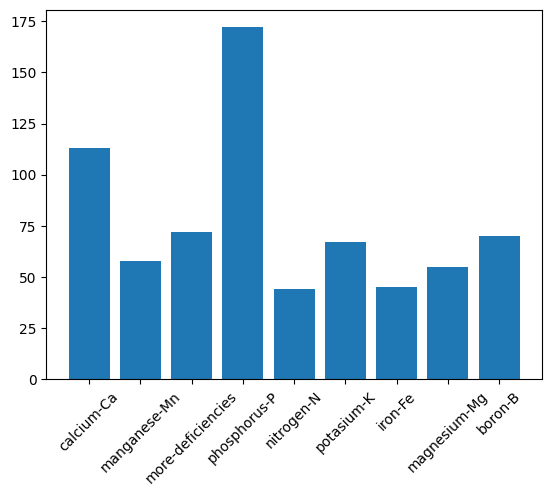

Clase calcium-Ca tiene 32 registros
Clase manganese-Mn tiene 16 registros
Clase more-deficiencies tiene 20 registros
Clase phosphorus-P tiene 49 registros
Clase nitrogen-N tiene 12 registros
Clase potasium-K tiene 19 registros
Clase iron-Fe tiene 13 registros
Clase magnesium-Mg tiene 15 registros
Clase boron-B tiene 20 registros


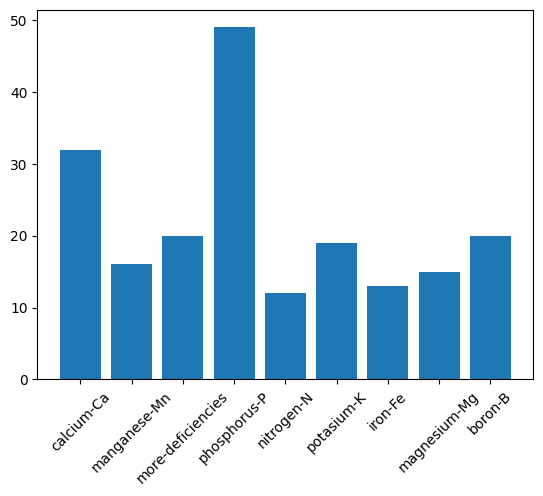

Clase calcium-Ca tiene 17 registros
Clase manganese-Mn tiene 9 registros
Clase more-deficiencies tiene 12 registros
Clase phosphorus-P tiene 25 registros
Clase nitrogen-N tiene 8 registros
Clase potasium-K tiene 10 registros
Clase iron-Fe tiene 7 registros
Clase magnesium-Mg tiene 9 registros
Clase boron-B tiene 11 registros


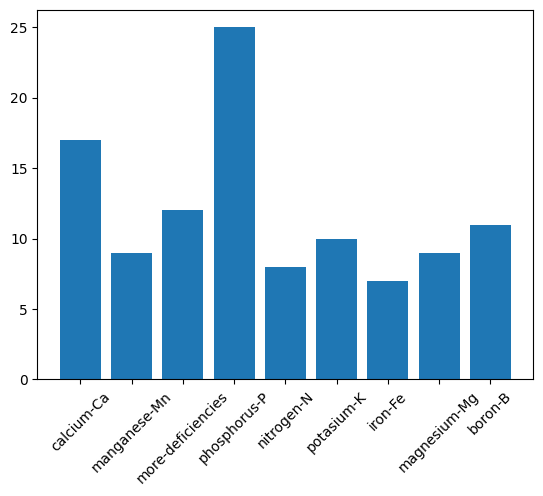

In [ ]:
DATA_PATH="/content/drive/MyDrive/DatasetCOLEAF_Recortado"
Show_data(DATA_PATH, "train")
Show_data(DATA_PATH, "valid")
Show_data(DATA_PATH, "test")

# Preprocesamiento


In [ ]:
train_dir = '/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido/train'
valid_dir = '/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido/valid'
#test_dir = '/content/drive/MyDrive/DatasetCOLEAF_Recortado/test'

In [ ]:
base_dir   = "/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido"
data_dir_train = '/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido/train'
data_dir_valid = '/content/drive/MyDrive/Replicado_80_20/DatasetCOLEAF_80_20_dividido/valid'
#data_dir_test = '/content/drive/MyDrive/DatasetCOLEAF_Recortado/test'

In [ ]:
# Usaremos ImageFolder de torchvision, que es más adecuado
# para datos organizados por carpetas.
# Mantenemos el nombre MyDataset por compatibilidad con DataModule.
class MyDataset(datasets.ImageFolder):
    def __init__(self, root, transform=None):
        # ImageFolder automáticamente encuentra las clases a partir
        # de los nombres de las carpetas dentro de 'root'
        super().__init__(root, transform=transform)

In [ ]:
class DataModule(pl.LightningDataModule):
    def __init__(self, dat_norm, img_size=224, batch_size=64,
                 train_dir=None, valid_dir=None, test_dir=None, categories=None):

        super().__init__()
        self.img_size = img_size

        # Transformaciones (las mismas)
        self.transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(dat_norm[0], dat_norm[1]),
        ])
        self.train_transform = transforms.Compose([
            # 1. Ajuste base
            transforms.Resize(size=(self.img_size, self.img_size)),

            # 2. Rotaciones y volteos (El celular de cabeza o de lado)
            transforms.RandomRotation(degrees=45),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),

            # 3. Encuadres imperfectos en el campo
            # translate=(0.1, 0.1) mueve la imagen hasta un 10% en cualquier dirección
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
            # distortion_scale=0.2 inclina la foto ligeramente en 3D (30% de probabilidad)
            transforms.RandomPerspective(distortion_scale=0.2, p=0.3),

            # 4. Problemas de iluminación (Sol fuerte, nublado, sombras)
            transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),

            # 5. Problemas de enfoque / Temblor de mano
            # Se aplica un desenfoque gaussiano solo al 30% de las fotos (p=0.3)
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),

            # 6. Conversión a tensores
            transforms.ToTensor(),
            transforms.Normalize(dat_norm[0], dat_norm[1]),
        ])

        self.batch_size = batch_size
        self.num_workers = multiprocessing.cpu_count()

        # Guardamos las rutas para cargarlas en setup()
        self.train_dir = train_dir
        self.valid_dir = valid_dir
        self.test_dir = test_dir

        # Estos se inicializarán como None y se cargarán en setup()
        self.traindata = None
        self.validdata = None
        self.testdata = None

    # setup() para cargar los datos usando ImageFolder (MyDataset)
    def setup(self, stage=None):
        if stage == 'fit' or stage is None:
            if self.train_dir:
                # La ruta del directorio de entrenamiento se pasa a MyDataset (ImageFolder)
                self.traindata = MyDataset(self.train_dir, self.train_transform)
            if self.valid_dir:
                self.validdata = MyDataset(self.valid_dir, self.transform)

        if stage == 'test' or stage is None:
            if self.test_dir:
                self.testdata = MyDataset(self.test_dir, self.transform)

    def train_dataloader(self):
        if self.traindata is None:
            raise RuntimeError("Train data not loaded. Check your train_dir path.")
        # --- AQUÍ OCURRE LA MAGIA DEL BALANCEO ---
        # 1. Contamos cuántas imágenes hay de cada clase
        targets = self.traindata.targets
        class_counts = torch.bincount(torch.tensor(targets))

        # 2. Le damos más "peso" (importancia) a las clases que tienen menos imágenes
        class_weights = 1.0 / class_counts.float()

        # 3. Asignamos ese peso a cada imagen individual en el dataset
        sample_weights = class_weights[targets]

        # 4. Creamos el sampler. Él se encargará de pedir más veces las fotos raras
        sampler = WeightedRandomSampler(
            weights=sample_weights,
            num_samples=len(sample_weights),
            replacement=True # Permite repetir la misma imagen rara en un mismo epoch (¡con nueva transformación!)
        )

        # OJO: Cuando usas 'sampler', NO puedes usar 'shuffle=True'
        return DataLoader(
            self.traindata,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            sampler=sampler, # Agregamos el sampler
            drop_last=True
        )

    def val_dataloader(self):
        if self.validdata is None:
             raise RuntimeError("Validation data not loaded. Check your valid_dir path.")
        return torch.utils.data.DataLoader(
            self.validdata, batch_size=self.batch_size, num_workers=self.num_workers, drop_last=False)

    def test_dataloader(self):
        if self.testdata is None:
             raise RuntimeError("Test data not loaded. Check your test_dir path.")
        return torch.utils.data.DataLoader(
            self.testdata, batch_size=self.batch_size, num_workers=0, drop_last=False)

**Modo Replicar sin test**

In [ ]:
class DataModule(pl.LightningDataModule):
    def __init__(self, dat_norm, img_size=224, batch_size=64,
                 train_dir=None, valid_dir=None, categories=None): # Se eliminó test_dir

        super().__init__()
        self.img_size = img_size

        # Transformaciones (las mismas)
        self.transform = transforms.Compose([
            transforms.Resize(size=(self.img_size, self.img_size)),
            transforms.ToTensor(),
            transforms.Normalize(dat_norm[0], dat_norm[1]),
        ])

        self.train_transform = transforms.Compose([
        # 1. Regresamos al Resize clásico. No queremos recortar ni perder bordes secos.
        transforms.Resize(size=(self.img_size, self.img_size)),

        # 2. Geometría Segura (No destruye píxeles, solo cambia la perspectiva)
        transforms.RandomRotation(degrees=45),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),

        # 3. Color Sutil (Como lo tenías en 0.1, pero bloqueando el cambio de Tono/Hue)
        transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0),

        # 4. Desenfoque al mínimo (Ayuda a generalizar sin borrar manchas, p=0.1)
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.1),

        # 5. Conversión y Normalización
        transforms.ToTensor(),
        transforms.Normalize(dat_norm[0], dat_norm[1]),

        # ELIMINADOS: RandomErasing y RandomAffine. Estaban tapando/moviendo las enfermedades.
        ])

        self.batch_size = batch_size
        self.num_workers = multiprocessing.cpu_count()

        # Guardamos las rutas para cargarlas en setup()
        self.train_dir = train_dir
        self.valid_dir = valid_dir
        # Se eliminó self.test_dir

        # Estos se inicializarán como None y se cargarán en setup()
        self.traindata = None
        self.validdata = None
        # Se eliminó self.testdata

    # setup() para cargar los datos usando ImageFolder (MyDataset)
    def setup(self, stage=None):
        # Ahora solo nos interesa la fase de ajuste ('fit')
        if stage == 'fit' or stage is None:
            if self.train_dir:
                # La ruta del directorio de entrenamiento se pasa a MyDataset (ImageFolder)
                self.traindata = MyDataset(self.train_dir, self.train_transform)
            if self.valid_dir:
                self.validdata = MyDataset(self.valid_dir, self.transform)

        # Se eliminó por completo el bloque "if stage == 'test': ..."

    def train_dataloader(self):
        if self.traindata is None:
            raise RuntimeError("Train data not loaded. Check your train_dir path.")

        return DataLoader(
            self.traindata,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            shuffle=True,
            drop_last=True
        )

    def val_dataloader(self):
        if self.validdata is None:
             raise RuntimeError("Validation data not loaded. Check your valid_dir path.")
        return torch.utils.data.DataLoader(
            self.validdata,
            batch_size=self.batch_size,
            num_workers=self.num_workers,
            drop_last=False
        )

    # Se eliminó por completo def test_dataloader(self)

In [ ]:
#Beta:
self.train_transform = transforms.Compose([
    # 1. Regresamos al Resize clásico. No queremos recortar ni perder bordes secos.
    transforms.Resize(size=(self.img_size, self.img_size)),

    # 2. Geometría Segura (No destruye píxeles, solo cambia la perspectiva)
    transforms.RandomRotation(degrees=45),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),

    # 3. Color Sutil (Como lo tenías en 0.1, pero bloqueando el cambio de Tono/Hue)
    transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1, hue=0),

    # 4. Desenfoque al mínimo (Ayuda a generalizar sin borrar manchas, p=0.1)
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0))], p=0.1),

    # 5. Conversión y Normalización
    transforms.ToTensor(),
    transforms.Normalize(dat_norm[0], dat_norm[1]),

    # 8. Normalización (Siempre al final)
    transforms.Normalize(dat_norm[0], dat_norm[1]),
])

# Train and Test

In [ ]:
#2
scaler = GradScaler()

def train(model, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc=0):
    log_interval = 10
    print("Begin training...")
    total = (len(train_loader) + len(valid_loader))*num_epochs
    n = len(list(model.parameters()))

    if porc > 0:
        print(f"APLICANDO FINE TUNING. \n Descongelando el {porc*100}% de capas.")
        for i, param in enumerate(model.parameters()):
            if i > n*(1-porc):
                param.requires_grad = True
    else:
        print(f"APLICANDO TRANSFER LEARNING. \n Entrenando Bloque añadido.")

    history = []
    lr_history = []
    best_f1 = 0
    best_accuracy = 0

    for epoch in range(1, num_epochs+1):
        model.train()
        running_train_loss = 0.0
        all_preds = []
        all_labels = []

        for batch_idx, (img, target) in enumerate(train_loader):
            img, target = img.to(device, non_blocking=True), target.to(device, non_blocking=True)

            # Limpiar gradientes del lote anterior
            optimizer.zero_grad()

            # Forward and backward propagation with mixed precision
            with torch.amp.autocast('cuda'):
                output = model(img)
                train_loss = criterion(output.float(), target)
            # Scales the loss, and calls backward() to create scaled gradients
            scaler.scale(train_loss).backward()

            # Unscales the gradients of optimizer's assigned params in-place
            scaler.step(optimizer)
            scaler.update()

            # Show progress
            running_train_loss += train_loss.item()
            all_preds.extend(output.float().argmax(dim=1).cpu().numpy())
            all_labels.extend(target.cpu().numpy())

            if batch_idx % log_interval == 0:
                print(f'Train Epoch: {epoch} [{batch_idx * len(img)}/{len(train_loader.dataset)} ({100. * batch_idx / len(train_loader):.0f}%)]\tLoss: {train_loss.item():.3f}')

        # Métricas de Entrenamiento de la época completa
        train_loss_value = running_train_loss / len(train_loader)
        train_f1 = f1_score(all_labels, all_preds, average='macro')

        # Validation Loop
        val_loss_value, accuracy, val_f1 = validation(model, valid_loader)
        history.append((train_loss_value, val_loss_value, accuracy, val_f1))

        # Step the scheduler
        scheduler.step(val_f1)
        lr_history.append(optimizer.param_groups[0]['lr'])

        print(f'COMPLETED Train Epoch {epoch}: Training Loss is: {train_loss_value:.3f} - Validation Loss is: {val_loss_value:.3f} - Accuracy is {accuracy:.2f}% - F1 Score is {val_f1:.4f}')

        if val_f1 > best_f1:
            print(f'Validation F1-Score increment: {best_f1:.4f} ⮕ {val_f1:.4f} | Acc: {best_accuracy:.2f}% ⮕ {accuracy:.2f}% \t Saving The Model')
            saveModel(model)
            best_accuracy = accuracy
            best_f1 = val_f1

    return model, history, lr_history

In [ ]:
#2
def validation(model, valid_loader):
    model.eval()
    running_vall_loss = 0.0
    total = 0.0
    running_accuracy = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for img, target in valid_loader:
            img, target = img.to(device), target.to(device)
            predicted_outputs = model(img)
            val_loss = criterion(predicted_outputs, target)
            _, predicted = torch.max(predicted_outputs, 1)
            running_vall_loss += val_loss.item()
            total += target.size(0)
            running_accuracy += (predicted == target).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

        val_loss_value = running_vall_loss / len(valid_loader)
        accuracy = (100 * running_accuracy / total)
        val_f1 = f1_score(all_labels, all_preds, average='macro')

    return val_loss_value, accuracy, val_f1

In [ ]:
#2
from sklearn.metrics import f1_score, classification_report
import torch
def test(model, criterion, device, test_loader, class_names):
    model.eval()
    test_loss = 0
    all_preds = []
    all_labels = []

    print("Iniciando Test...")
    with torch.no_grad():
        for img, target in test_loader:
            img, target = img.to(device), target.to(device)
            output = model(img)
            test_loss += criterion(output, target).item()
            # 2. Obtenemos la clase predicha directamente
            _, predicted = torch.max(output, 1)

            # 3. Pasamos a CPU y guardamos en la lista (ESTO ES LO EFICIENTE)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    test_loss /= len(test_loader)
    y_true = all_labels
    y_pred = all_preds
    print(f'Test set: Average loss: {test_loss:.4f}')
    print(f'Test set: Accuracy score: {sk_metrics.accuracy_score(y_true, y_pred):.4f}')
    print(f'Test set: Macro F1 score: {sk_metrics.f1_score(y_true, y_pred, average="macro"):.4f}')
      # Imprimir el reporte detallado por clase

    print("\nREPORTE DETALLADO POR CLASE:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    print('='*60 + '\n')
    return y_pred, y_true

## **Modelo VGG-16**

In [ ]:
def saveModel(model):
    dir_Save ="/content/new_dataVGG16"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
class CNN_VGG16(nn.Module):
    def __init__(self, num_classes = 10, pretrained = True):
        super().__init__()

        self.num_classes = num_classes

        # Para VGG16
        self.vgg = timm.create_model("vgg16", pretrained = pretrained)
        if pretrained:
          # freeze  weights
            for param in self.vgg.parameters():
              param.requires_grad = False

        self.numfeat = self.vgg.get_classifier().in_features

        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes))

        self.vgg.head.fc = block

    def forward(self, x):
        out = self.vgg(x)
        return out

    def get_mean_std(self):
      return self.vgg.default_cfg["mean"], self.vgg.default_cfg["std"]

### **Configurando Hiperparámetros**

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
from torch.optim.lr_scheduler import ReduceLROnPlateau
num_class  = 9
lr         = 1e-4
num_epochs  = 50
batch_size = 64
img_size   = 224

model_cnn = CNN_VGG16(num_classes=num_class).to(device)
criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

model.safetensors:   0%|          | 0.00/553M [00:00<?, ?B/s]

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir=train_dir, valid_dir=valid_dir, test_dir=test_dir )
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()

In [ ]:
wmodel_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs= num_epochs, porc = 0.30)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 30.0% de capas.
Train Epoch: 1 [0/696 (0%)]	Loss: 2.221
COMPLETED Train Epoch 1: Training Loss is: 2.019 - Validation Loss is: 1.641 - Accuracy is 44.90% - F1 Score is 0.3139
Validation F1-Score increment: 0.0000 ⮕ 0.3139 | Acc: 0.00% ⮕ 44.90% 	 Saving The Model
Train Epoch: 2 [0/696 (0%)]	Loss: 1.654
COMPLETED Train Epoch 2: Training Loss is: 1.505 - Validation Loss is: 1.125 - Accuracy is 53.57% - F1 Score is 0.4623
Validation F1-Score increment: 0.3139 ⮕ 0.4623 | Acc: 44.90% ⮕ 53.57% 	 Saving The Model
Train Epoch: 3 [0/696 (0%)]	Loss: 1.467
COMPLETED Train Epoch 3: Training Loss is: 1.312 - Validation Loss is: 1.098 - Accuracy is 47.45% - F1 Score is 0.4263
Train Epoch: 4 [0/696 (0%)]	Loss: 1.133
COMPLETED Train Epoch 4: Training Loss is: 1.236 - Validation Loss is: 1.071 - Accuracy is 49.49% - F1 Score is 0.4467
Train Epoch: 5 [0/696 (0%)]	Loss: 1.201
COMPLETED Train Epoch 5: Training Loss is: 1.179 - Validation Loss is: 

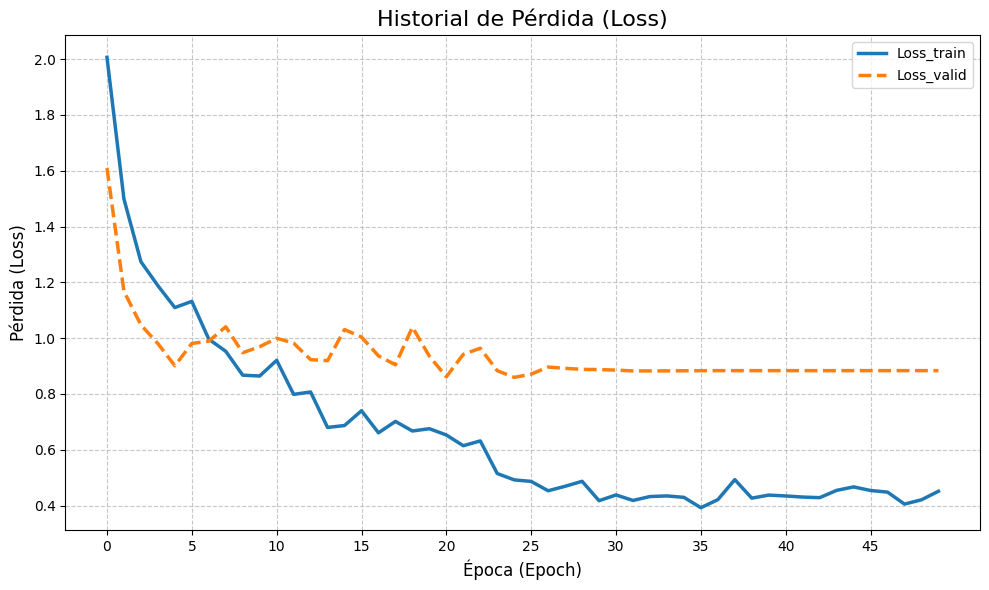

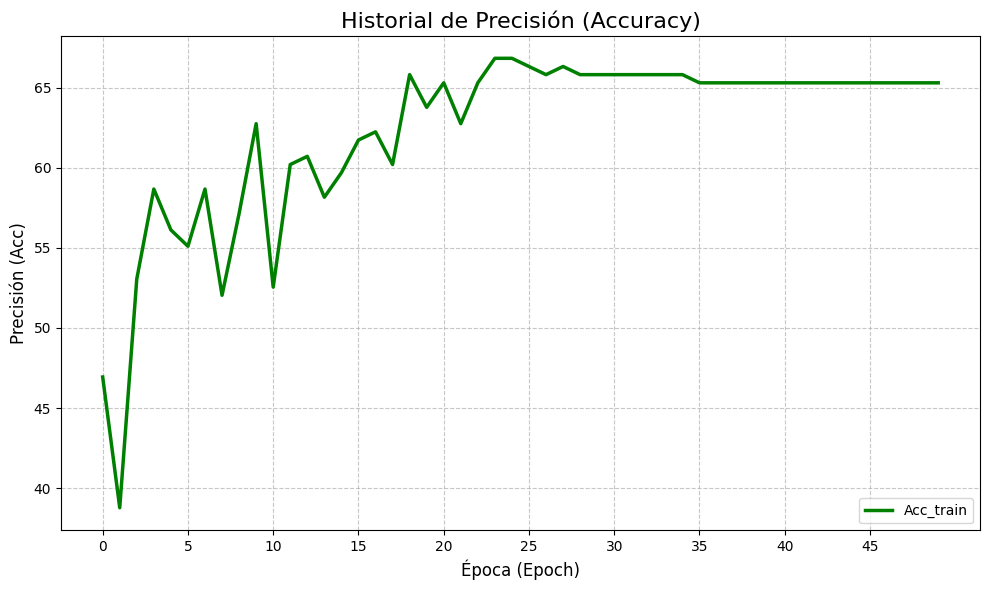

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando mejor Modelo


In [ ]:
model_sv = CNN_VGG16(num_classes=num_class).to(device)
path = "/content/new_dataVGG16/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
test_loader = dm.test_dataloader()
loader = test_loader
labels = list(dm.testdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 0.9363
Test set: Accuracy score: 0.6944
Test set: Macro F1 score: 0.6632

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.6923    0.8182    0.7500        11
       calcium-Ca     0.8125    0.7647    0.7879        17
          iron-Fe     0.6667    0.8571    0.7500         7
     magnesium-Mg     0.5000    0.6667    0.5714         9
     manganese-Mn     0.7143    0.5556    0.6250         9
more-deficiencies     0.6000    0.2500    0.3529        12
       nitrogen-N     0.6667    0.5000    0.5714         8
     phosphorus-P     0.7600    0.7600    0.7600        25
       potasium-K     0.6667    1.0000    0.8000        10

         accuracy                         0.6944       108
        macro avg     0.6755    0.6858    0.6632       108
     weighted avg     0.6965    0.6944    0.6803       108




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

**Pruebas**

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.testdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.69      0.82      0.75        11
       calcium-Ca       0.81      0.76      0.79        17
          iron-Fe       0.67      0.86      0.75         7
     magnesium-Mg       0.50      0.67      0.57         9
     manganese-Mn       0.71      0.56      0.62         9
more-deficiencies       0.60      0.25      0.35        12
       nitrogen-N       0.67      0.50      0.57         8
     phosphorus-P       0.76      0.76      0.76        25
       potasium-K       0.67      1.00      0.80        10

         accuracy                           0.69       108
        macro avg       0.68      0.69      0.66       108
     weighted avg       0.70      0.69      0.68       108



# InceptionV3

In [ ]:
def saveModel(model):
    dir_Save ="/content/new_dataInceptionV3"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

Modelo InceptionV3

In [ ]:
class CNN_IV3(nn.Module):
    def __init__(self, num_classes = 10, pretrained = True):
        super().__init__()

        self.num_classes = num_classes

        # Para IncpetionV3
        self.inception_v3 = timm.create_model("inception_v3", pretrained = pretrained)
        if pretrained:
          # freeze  weights
            for param in self.inception_v3.parameters():
              param.requires_grad = False

        self.numfeat = self.inception_v3.get_classifier().in_features

        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes))

        self.inception_v3.fc = block

    def forward(self, x):
        out = self.inception_v3.forward(x)
        return out

    def get_mean_std(self):
      return self.inception_v3.default_cfg["mean"], self.inception_v3.default_cfg["std"]

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

gc.collect()
torch.cuda.empty_cache()

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
num_class  = 9
lr         = 1e-4
num_epochs  = 50
batch_size = 32
img_size   = 224

model_cnn = CNN_IV3(num_classes=num_class).to(device)
criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir, test_dir=test_dir )
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

### **Entrenando el Modelo**

In [ ]:
model_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc = 0.30)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 30.0% de capas.
Train Epoch: 1 [0/696 (0%)]	Loss: 2.193
COMPLETED Train Epoch 1: Training Loss is: 2.179 - Validation Loss is: 2.151 - Accuracy is 19.39% - F1 Score is 0.1415
Validation F1-Score increment: 0.0000 ⮕ 0.1415 | Acc: 0.00% ⮕ 19.39% 	 Saving The Model
Train Epoch: 2 [0/696 (0%)]	Loss: 2.093
COMPLETED Train Epoch 2: Training Loss is: 2.069 - Validation Loss is: 1.989 - Accuracy is 44.90% - F1 Score is 0.3500
Validation F1-Score increment: 0.1415 ⮕ 0.3500 | Acc: 19.39% ⮕ 44.90% 	 Saving The Model
Train Epoch: 3 [0/696 (0%)]	Loss: 2.014
COMPLETED Train Epoch 3: Training Loss is: 1.915 - Validation Loss is: 1.900 - Accuracy is 36.22% - F1 Score is 0.3670
Validation F1-Score increment: 0.3500 ⮕ 0.3670 | Acc: 44.90% ⮕ 36.22% 	 Saving The Model
Train Epoch: 4 [0/696 (0%)]	Loss: 1.787
COMPLETED Train Epoch 4: Training Loss is: 1.718 - Validation Loss is: 1.727 - Accuracy is 47.96% - F1 Score is 0.3743
Validation F1-Score in

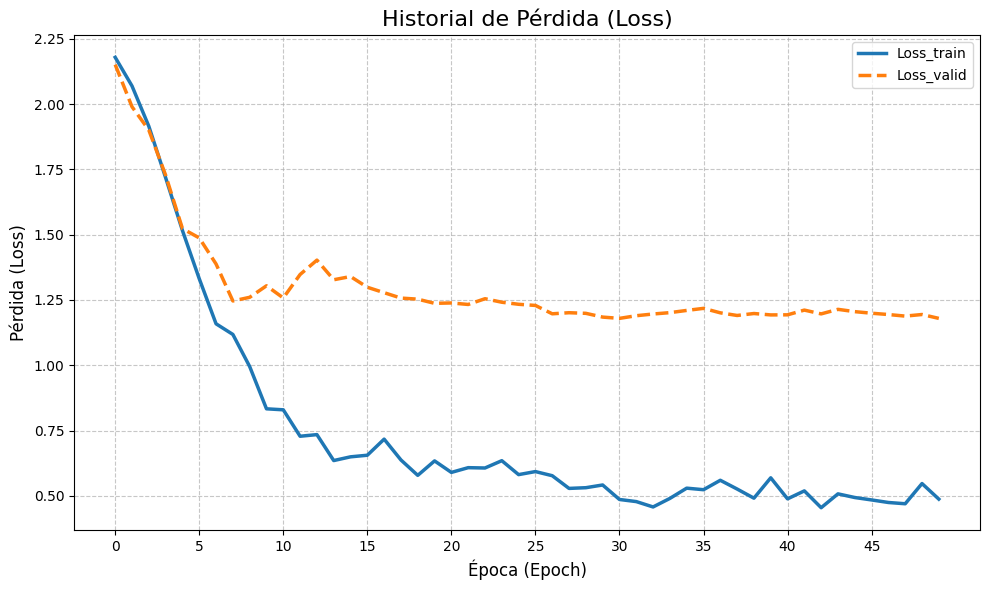

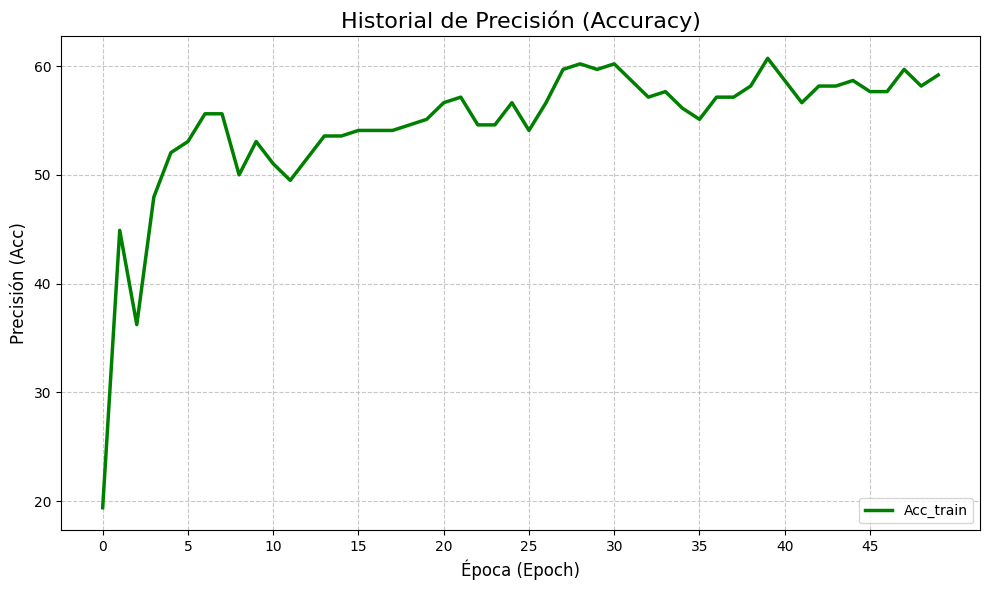

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [ ]:
model_sv = CNN_IV3(num_classes=num_class).to(device)
path = "/content/new_dataInceptionV3/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
loader = test_loader
labels = list(dm.testdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 0.9453
Test set: Accuracy score: 0.6019
Test set: Macro F1 score: 0.5901

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.6000    0.8182    0.6923        11
       calcium-Ca     0.7857    0.6471    0.7097        17
          iron-Fe     0.6364    1.0000    0.7778         7
     magnesium-Mg     0.4615    0.6667    0.5455         9
     manganese-Mn     0.7143    0.5556    0.6250         9
more-deficiencies     0.2143    0.2500    0.2308        12
       nitrogen-N     0.3333    0.2500    0.2857         8
     phosphorus-P     0.7500    0.6000    0.6667        25
       potasium-K     0.8750    0.7000    0.7778        10

         accuracy                         0.6019       108
        macro avg     0.5967    0.6097    0.5901       108
     weighted avg     0.6272    0.6019    0.6033       108




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

**Pruebas**

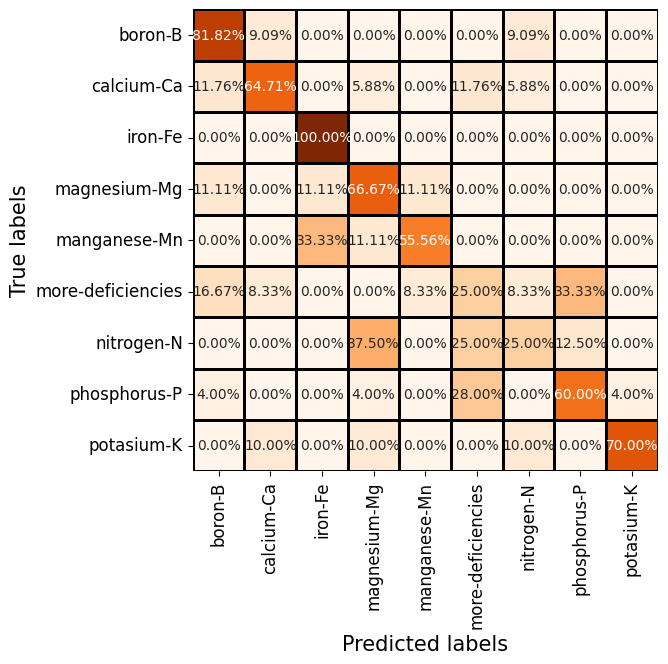

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.testdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.60      0.82      0.69        11
       calcium-Ca       0.79      0.65      0.71        17
          iron-Fe       0.64      1.00      0.78         7
     magnesium-Mg       0.46      0.67      0.55         9
     manganese-Mn       0.71      0.56      0.62         9
more-deficiencies       0.21      0.25      0.23        12
       nitrogen-N       0.33      0.25      0.29         8
     phosphorus-P       0.75      0.60      0.67        25
       potasium-K       0.88      0.70      0.78        10

         accuracy                           0.60       108
        macro avg       0.60      0.61      0.59       108
     weighted avg       0.63      0.60      0.60       108



# ResNet200d

In [ ]:
def saveModel(model):
    dir_Save ="/content/new_data"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

### **Modelo Resnet200d**

In [ ]:
class CNN_RESNET(nn.Module):
    def __init__(self, num_classes = 4, pretrained = True):
        super().__init__()

        self.num_classes = num_classes

        # Para RESNET
        self.resnet = timm.create_model("resnet200d", pretrained = pretrained)
        if pretrained:
          # freeze  weights
            for param in self.resnet.parameters():
              param.requires_grad = False

        self.numfeat = self.resnet.get_classifier().in_features

        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes))

        self.resnet.fc = block

    def forward(self, x):
        out = self.resnet.forward(x)
        return out

    def get_mean_std(self):
      return self.resnet.default_cfg["mean"], self.resnet.default_cfg["std"]

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(48110)


In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
num_class  = 9
lr         = 1e-4
num_epochs  = 100
batch_size = 64
img_size   = 224

model_cnn = CNN_RESNET(num_classes=num_class).to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

model.safetensors:   0%|          | 0.00/260M [00:00<?, ?B/s]

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir)
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
#test_loader = dm.test_dataloader()

In [ ]:
# =================================================================
# CÁLCULO DE PESOS
# =================================================================
# 1. Extraemos las etiquetas usando tu variable 'dm'
etiquetas_train = dm.traindata.targets

# 2. Contamos cuántas imágenes hay por clase y aplicamos la fórmula
conteo_clases = torch.bincount(torch.tensor(etiquetas_train))
total_muestras = len(etiquetas_train)
num_clases = len(conteo_clases)

pesos_clases = total_muestras / (num_clases * conteo_clases.float())
pesos_tensor = pesos_clases.to(device)

print("="*50)
print(f"⚖️ Pesos matemáticos calculados para las {num_clases} clases:")
print(pesos_tensor)
print("="*50)

# 3 CRITERION CON PESOS INYECTADOS
criterion = nn.CrossEntropyLoss(weight=pesos_tensor).to(device)

⚖️ Pesos matemáticos calculados para las 9 clases:
tensor([1.1056, 0.6856, 1.7009, 1.4039, 1.3401, 1.0656, 1.7342, 0.4512, 1.1637],
       device='cuda:0')


***Entrenamiento del modelo***

In [ ]:
model_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc = 0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 30.0% de capas.
Train Epoch: 1 [0/796 (0%)]	Loss: 2.200
Train Epoch: 1 [640/796 (83%)]	Loss: 2.130
COMPLETED Train Epoch 1: Training Loss is: 2.167 - Validation Loss is: 2.106 - Accuracy is 35.78% - F1 Score is 0.2611
Validation F1-Score increment: 0.0000 ⮕ 0.2611 | Acc: 0.00% ⮕ 35.78% 	 Saving The Model
Train Epoch: 2 [0/796 (0%)]	Loss: 2.033
Train Epoch: 2 [640/796 (83%)]	Loss: 1.861
COMPLETED Train Epoch 2: Training Loss is: 1.956 - Validation Loss is: 1.861 - Accuracy is 44.61% - F1 Score is 0.3630
Validation F1-Score increment: 0.2611 ⮕ 0.3630 | Acc: 35.78% ⮕ 44.61% 	 Saving The Model
Train Epoch: 3 [0/796 (0%)]	Loss: 1.825
Train Epoch: 3 [640/796 (83%)]	Loss: 1.478
COMPLETED Train Epoch 3: Training Loss is: 1.577 - Validation Loss is: 1.477 - Accuracy is 58.33% - F1 Score is 0.5286
Validation F1-Score increment: 0.3630 ⮕ 0.5286 | Acc: 44.61% ⮕ 58.33% 	 Saving The Model
Train Epoch: 4 [0/796 (0%)]	Loss: 1.162
Train Epoch:

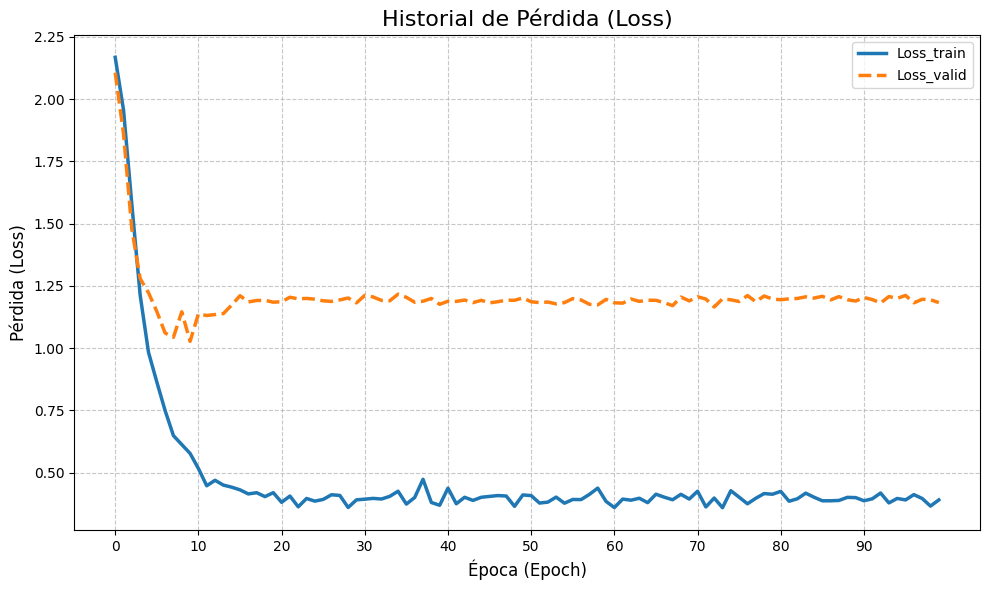

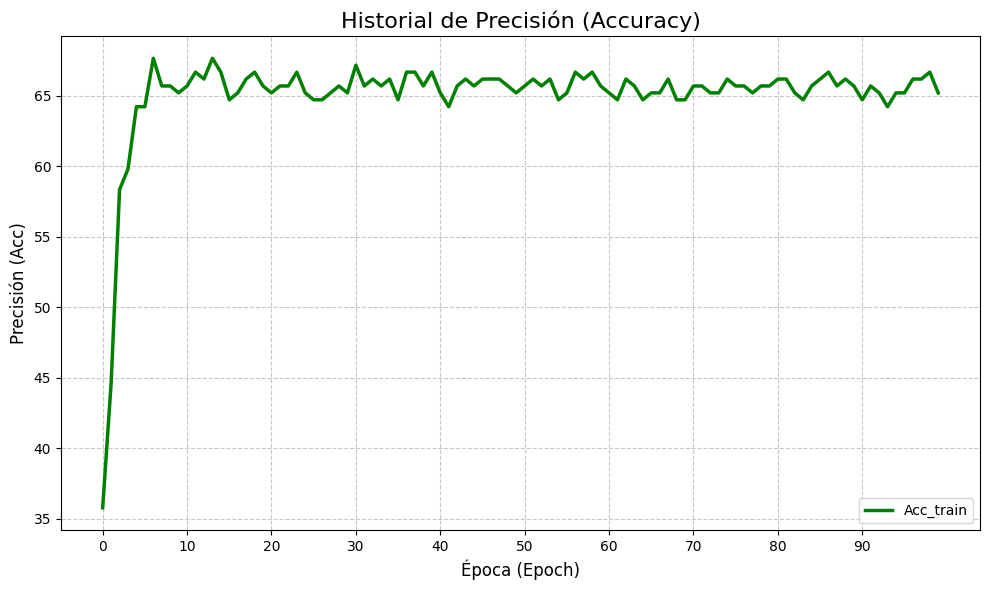

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el Mejor Modelo

In [ ]:
model_sv = CNN_RESNET(num_classes=num_class).to(device)
path = "/content/new_data/NetModel.pth"
#model_sv.load_state_dict(torch.load(path))
model_sv.load_state_dict(torch.load(path, map_location=torch.device('cuda')))

<All keys matched successfully>

In [ ]:
loader = valid_loader
labels = list(dm.validdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 1.1385
Test set: Accuracy score: 0.6765
Test set: Macro F1 score: 0.6380

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.8235    0.6667    0.7368        21
       calcium-Ca     0.8966    0.7879    0.8387        33
          iron-Fe     0.7333    0.8462    0.7857        13
     magnesium-Mg     0.4737    0.5625    0.5143        16
     manganese-Mn     0.5882    0.5882    0.5882        17
more-deficiencies     0.3214    0.4286    0.3673        21
       nitrogen-N     0.5385    0.5385    0.5385        13
     phosphorus-P     0.8269    0.8600    0.8431        50
       potasium-K     0.6429    0.4500    0.5294        20

         accuracy                         0.6765       204
        macro avg     0.6494    0.6365    0.6380       204
     weighted avg     0.6958    0.6765    0.6816       204




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

**Pruebas**

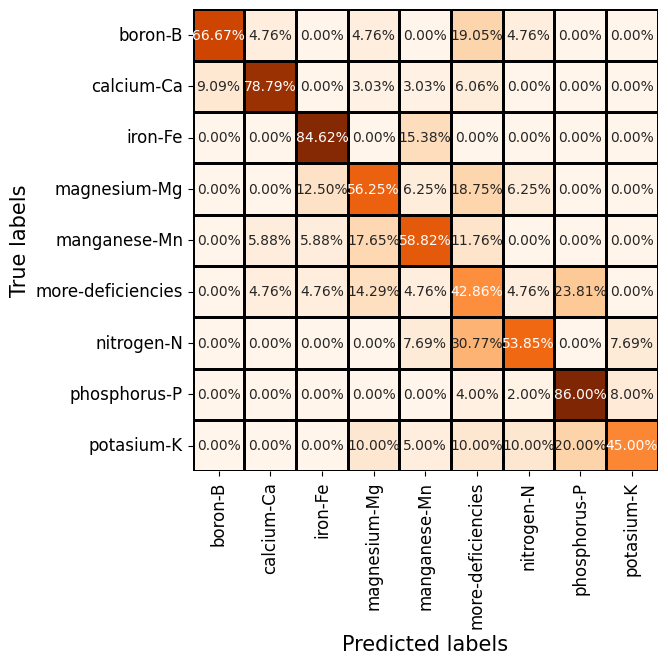

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.validdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.82      0.67      0.74        21
       calcium-Ca       0.90      0.79      0.84        33
          iron-Fe       0.73      0.85      0.79        13
     magnesium-Mg       0.47      0.56      0.51        16
     manganese-Mn       0.59      0.59      0.59        17
more-deficiencies       0.32      0.43      0.37        21
       nitrogen-N       0.54      0.54      0.54        13
     phosphorus-P       0.83      0.86      0.84        50
       potasium-K       0.64      0.45      0.53        20

         accuracy                           0.68       204
        macro avg       0.65      0.64      0.64       204
     weighted avg       0.70      0.68      0.68       204



# Google Vit


In [ ]:
from transformers import ViTImageProcessor, ViTForImageClassification
import requests

In [ ]:
def saveModel(model):
    dir_Save ="/content/new_dataGVIT"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
#@title google/vit-base-patch16-224
class GVIT(nn.Module):
    def __init__(self, num_classes = 10, pretrained=True):
        super().__init__()

        self.num_classes = num_classes

        ########
        processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
        self.backbone =  ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

        if pretrained:
          # freeze  weights
            for param in self.backbone.parameters():
              param.requires_grad = False

        self.numfeat = self.backbone.classifier.in_features
        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes))

        self.backbone.classifier = block
        ##########

    def forward(self, x):
      output = self.backbone(x)
      #print(output.logits)
      return output.logits



    def get_mean_std(self):
      return (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)
      #return self.backbone.default_cfg["mean"], self.backbone.default_cfg["std"]


In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

In [ ]:
num_class  = 9
lr         = 1e-4
num_epochs  = 50
batch_size = 32
img_size   = 224

model_cnn = GVIT(num_classes=num_class).to(device)
criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir, test_dir=test_dir )
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

In [ ]:
model_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc = 0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 0.4% de capas.
Train Epoch: 1 [0/700 (0%)]	Loss: 2.240
COMPLETED Train Epoch 1: Training Loss is: 2.057 - Validation Loss is: 1.645 - Accuracy is 40.61% - F1 Score is 0.1230
Validation F1-Score increment (0.000 + 0.000) ---> (0.123 + 40.609) 	 Saving The Model
Train Epoch: 2 [0/700 (0%)]	Loss: 1.676
COMPLETED Train Epoch 2: Training Loss is: 1.632 - Validation Loss is: 1.316 - Accuracy is 54.82% - F1 Score is 0.3517
Validation F1-Score increment (0.123 + 40.609) ---> (0.352 + 54.822) 	 Saving The Model
Train Epoch: 3 [0/700 (0%)]	Loss: 1.397
COMPLETED Train Epoch 3: Training Loss is: 1.305 - Validation Loss is: 1.104 - Accuracy is 58.88% - F1 Score is 0.4030
Validation F1-Score increment (0.352 + 54.822) ---> (0.403 + 58.883) 	 Saving The Model
Train Epoch: 4 [0/700 (0%)]	Loss: 1.269
COMPLETED Train Epoch 4: Training Loss is: 1.107 - Validation Loss is: 0.980 - Accuracy is 58.38% - F1 Score is 0.4354
Validation F1-Score increm

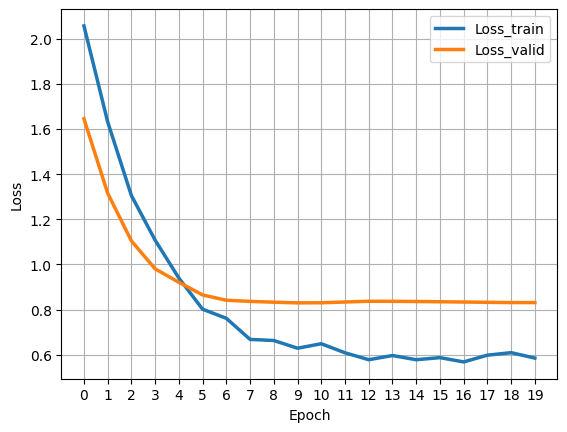

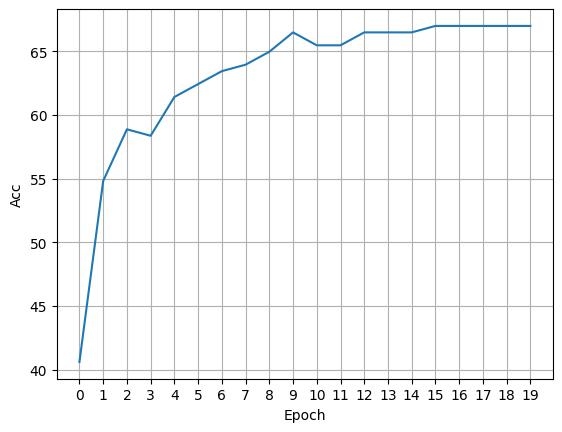

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [ ]:
model_sv = GVIT(num_classes=num_class).to(device)
path = "/content/new_dataGVIT/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
loader = test_loader
labels = list(dm.testdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Test set: Average loss: 1.0157
Test set: Accuracy score: 0.5034
Test set: Macro F1 score: 0.5034
REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.6000    0.8182    0.6923        11
       calcium-Ca     0.8235    0.8235    0.8235        17
          healthy     0.0000    0.0000    0.0000         1
          iron-Fe     0.6667    0.5714    0.6154         7
     magnesium-Mg     0.3846    0.5556    0.4545         9
     manganese-Mn     0.4286    0.3333    0.3750         9
more-deficiencies     0.1429    0.1667    0.1538        12
       nitrogen-N     1.0000    0.2500    0.4000         8
     phosphorus-P     0.8261    0.7600    0.7917        25
       potasium-K     0.6667    0.8000    0.7273        10

         accuracy                         0.6055       109
        macro avg     0.5539    0.5079    0.5034       109
     weighted avg     0.6387    0.6055    0.6009       109




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

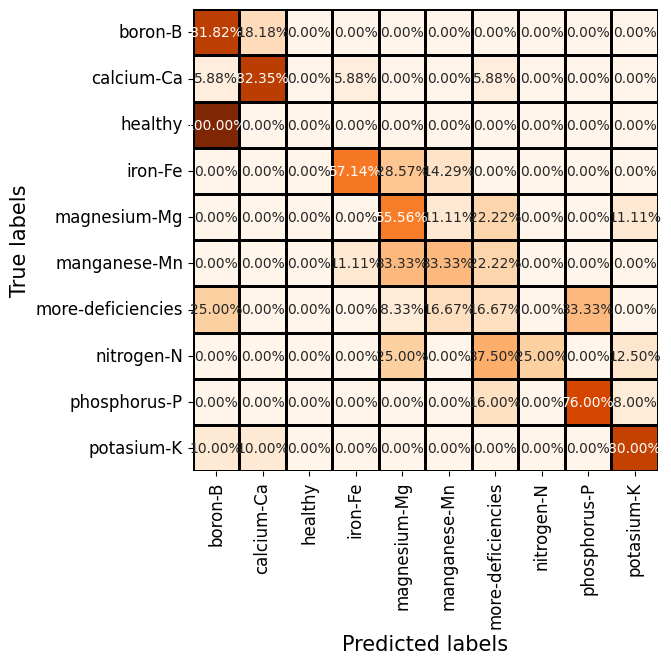

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.testdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.60      0.82      0.69        11
       calcium-Ca       0.82      0.82      0.82        17
          healthy       0.00      0.00      0.00         1
          iron-Fe       0.67      0.57      0.62         7
     magnesium-Mg       0.38      0.56      0.45         9
     manganese-Mn       0.43      0.33      0.38         9
more-deficiencies       0.14      0.17      0.15        12
       nitrogen-N       1.00      0.25      0.40         8
     phosphorus-P       0.83      0.76      0.79        25
       potasium-K       0.67      0.80      0.73        10

         accuracy                           0.61       109
        macro avg       0.55      0.51      0.50       109
     weighted avg       0.64      0.61      0.60       109



# Swin_transformer

In [ ]:
def saveModel(model):
    dir_Save ="/content/new_dataSWIN"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
import torch
import torch.nn as nn
import timm

class CNN_SWIN(nn.Module):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__()
        self.num_classes = num_classes

        # Initialize with num_classes=0 to get features without a classifier head
        self.swin = timm.create_model("swin_base_patch4_window7_224", pretrained=pretrained, num_classes=10)

        if pretrained:
            for param in self.swin.parameters():
                param.requires_grad = False

        # Dummy forward para obtener el tamaño de las features
        dummy_input = torch.randn(1, 3, 224, 224)
        with torch.no_grad():
            # forward_features devuelve (Batch, H, W, C) en Swin
            features = self.swin.forward_features(dummy_input)
            self.numfeat = features.shape[-1]

        self.classifier_head = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        # 1. Obtener features del backbone
        # Shape output: (Batch, H, W, C) -> Ejemplo: (128, 7, 7, 1024)
        features = self.swin.forward_features(x)

        # 2. APLICAR GLOBAL POOLING (ESTA ES LA CORRECCIÓN)
        # Necesitamos convertir (Batch, H, W, C) -> (Batch, C)
        # Movemos las dimensiones para que coincida con el formato de PyTorch (B, C, H, W)
        features = features.permute(0, 3, 1, 2)
        # Aplicamos un promedio global para reducir H y W a 1x1
        features = nn.functional.adaptive_avg_pool2d(features, (1, 1))
        # Aplanamos para que quede (Batch, Channels)
        features = features.flatten(1)

        # 3. Aplicar el clasificador
        # Input shape: (Batch, 1024) -> Output: (Batch, 10)
        out = self.classifier_head(features)
        return out

    def get_mean_std(self):
        return self.swin.default_cfg["mean"], self.swin.default_cfg["std"]

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
num_class  = 9
lr         = 1e-4
num_epochs  = 100
batch_size = 64
img_size   = 224

model_cnn = CNN_SWIN(num_classes=num_class).to(device)
#criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)


In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir)
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
#test_loader = dm.test_dataloader()

In [ ]:
# =================================================================
# CÁLCULO DE PESOS
# =================================================================
# 1. Extraemos las etiquetas usando tu variable 'dm'
etiquetas_train = dm.traindata.targets

# 2. Contamos cuántas imágenes hay por clase y aplicamos la fórmula
conteo_clases = torch.bincount(torch.tensor(etiquetas_train))
total_muestras = len(etiquetas_train)
num_clases = len(conteo_clases)

pesos_clases = total_muestras / (num_clases * conteo_clases.float())
pesos_tensor = pesos_clases.to(device).float()


print("="*50)
print(f"⚖️ Pesos matemáticos calculados para las {num_clases} clases:")
print(pesos_tensor)
print("="*50)

# 3 CRITERION CON PESOS INYECTADOS
#criterion = nn.CrossEntropyLoss(weight=pesos_tensor, label_smoothing=0.1).to(device)
criterion = nn.CrossEntropyLoss(weight=pesos_tensor).to(device)

In [ ]:
model_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc = 0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 0.4% de capas.
Train Epoch: 1 [0/700 (0%)]	Loss: 2.322
COMPLETED Train Epoch 1: Training Loss is: 2.071 - Validation Loss is: 1.559 - Accuracy is 40.61% - F1 Score is 0.1144
Validation F1-Score increment (0.000 + 0.000) ---> (0.114 + 40.609) 	 Saving The Model
Train Epoch: 2 [0/700 (0%)]	Loss: 1.758
COMPLETED Train Epoch 2: Training Loss is: 1.567 - Validation Loss is: 1.109 - Accuracy is 57.87% - F1 Score is 0.3878
Validation F1-Score increment (0.114 + 40.609) ---> (0.388 + 57.868) 	 Saving The Model
Train Epoch: 3 [0/700 (0%)]	Loss: 1.320
COMPLETED Train Epoch 3: Training Loss is: 1.204 - Validation Loss is: 0.955 - Accuracy is 59.90% - F1 Score is 0.4226
Validation F1-Score increment (0.388 + 57.868) ---> (0.423 + 59.898) 	 Saving The Model
Train Epoch: 4 [0/700 (0%)]	Loss: 1.004
COMPLETED Train Epoch 4: Training Loss is: 1.032 - Validation Loss is: 0.864 - Accuracy is 64.97% - F1 Score is 0.4941
Validation F1-Score increm

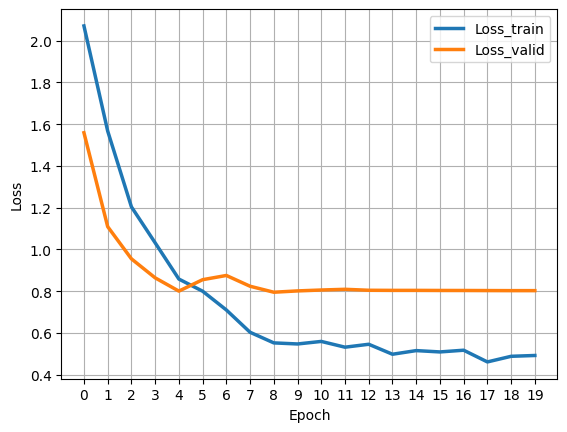

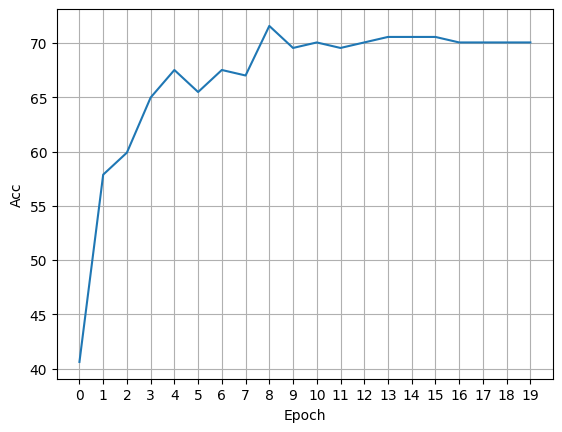

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [ ]:
model_sv = CNN_SWIN(num_classes=num_class).to(device)
path = "/content/new_dataSWIN/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
loader = valid_loader
labels = list(dm.validdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Test set: Average loss: 0.9521
Test set: Accuracy score: 0.5606
Test set: Macro F1 score: 0.5606
REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.7692    0.9091    0.8333        11
       calcium-Ca     0.8235    0.8235    0.8235        17
          healthy     0.0000    0.0000    0.0000         1
          iron-Fe     0.8333    0.7143    0.7692         7
     magnesium-Mg     0.5000    0.5556    0.5263         9
     manganese-Mn     0.4545    0.5556    0.5000         9
more-deficiencies     0.3333    0.2500    0.2857        12
       nitrogen-N     1.0000    0.1250    0.2222         8
     phosphorus-P     0.8148    0.8800    0.8462        25
       potasium-K     0.6667    1.0000    0.8000        10

         accuracy                         0.6881       109
        macro avg     0.6195    0.5813    0.5606       109
     weighted avg     0.6965    0.6881    0.6619       109




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

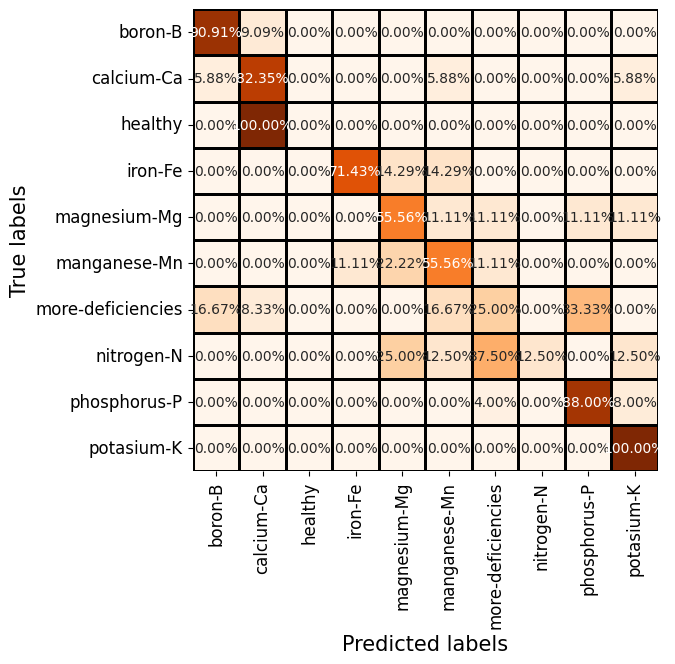

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.validdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.77      0.91      0.83        11
       calcium-Ca       0.82      0.82      0.82        17
          healthy       0.00      0.00      0.00         1
          iron-Fe       0.83      0.71      0.77         7
     magnesium-Mg       0.50      0.56      0.53         9
     manganese-Mn       0.45      0.56      0.50         9
more-deficiencies       0.33      0.25      0.29        12
       nitrogen-N       1.00      0.12      0.22         8
     phosphorus-P       0.81      0.88      0.85        25
       potasium-K       0.67      1.00      0.80        10

         accuracy                           0.69       109
        macro avg       0.62      0.58      0.56       109
     weighted avg       0.70      0.69      0.66       109



# nateraw/vit-base-patch16-224-cifar10

In [ ]:
def saveModel(model):
    dir_Save ="/content/Nat"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
from PIL import Image
import requests
from transformers import ViTImageProcessor, ViTForImageClassification

class NaterawVIT(nn.Module):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__()

        self.num_classes = num_classes

        ########
        # Cargar el procesador de imágenes y el modelo preentrenado
        self.processor = ViTImageProcessor.from_pretrained('nateraw/vit-base-patch16-224-cifar10')
        self.backbone = ViTForImageClassification.from_pretrained('nateraw/vit-base-patch16-224-cifar10')

        if pretrained:
            # Congelar los pesos del modelo
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Obtener el número de características de la capa clasificadora
        self.numfeat = self.backbone.classifier.in_features

        # Definir un nuevo bloque de clasificación
        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes)
        )

        # Reemplazar la capa clasificadora del modelo con el nuevo bloque
        self.backbone.classifier = block
        ##########

    def forward(self, x):
        output = self.backbone(x)
        return output.logits

    def get_mean_std(self):
        return (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)


In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
num_class  = 9
lr         = 1e-4
num_epochs  = 100
batch_size = 64
img_size   = 224

model_cnn = NaterawVIT(num_classes=num_class).to(device)
#criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/918 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/343M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir)
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
#test_loader = dm.test_dataloader()

In [ ]:
# =================================================================
# CÁLCULO DE PESOS
# =================================================================
# 1. Extraemos las etiquetas usando tu variable 'dm'
etiquetas_train = dm.traindata.targets

# 2. Contamos cuántas imágenes hay por clase y aplicamos la fórmula
conteo_clases = torch.bincount(torch.tensor(etiquetas_train))
total_muestras = len(etiquetas_train)
num_clases = len(conteo_clases)

pesos_clases = total_muestras / (num_clases * conteo_clases.float())
pesos_tensor = pesos_clases.to(device).float()


print("="*50)
print(f"⚖️ Pesos matemáticos calculados para las {num_clases} clases:")
print(pesos_tensor)
print("="*50)

# 3 CRITERION CON PESOS INYECTADOS
#criterion = nn.CrossEntropyLoss(weight=pesos_tensor, label_smoothing=0.1).to(device)
criterion = nn.CrossEntropyLoss(weight=pesos_tensor).to(device)

⚖️ Pesos matemáticos calculados para las 9 clases:
tensor([1.1056, 0.6856, 1.7009, 1.4039, 1.3401, 1.0656, 1.7342, 0.4512, 1.1637],
       device='cuda:0')


In [ ]:
model_cnn, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc = 0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 30.0% de capas.
Train Epoch: 1 [0/796 (0%)]	Loss: 2.195
Train Epoch: 1 [640/796 (83%)]	Loss: 2.032
COMPLETED Train Epoch 1: Training Loss is: 2.128 - Validation Loss is: 1.978 - Accuracy is 49.51% - F1 Score is 0.3946
Validation F1-Score increment: 0.0000 ⮕ 0.3946 | Acc: 0.00% ⮕ 49.51% 	 Saving The Model
Train Epoch: 2 [0/796 (0%)]	Loss: 2.026
Train Epoch: 2 [640/796 (83%)]	Loss: 1.694
COMPLETED Train Epoch 2: Training Loss is: 1.867 - Validation Loss is: 1.683 - Accuracy is 55.39% - F1 Score is 0.4151
Validation F1-Score increment: 0.3946 ⮕ 0.4151 | Acc: 49.51% ⮕ 55.39% 	 Saving The Model
Train Epoch: 3 [0/796 (0%)]	Loss: 1.734
Train Epoch: 3 [640/796 (83%)]	Loss: 1.458
COMPLETED Train Epoch 3: Training Loss is: 1.561 - Validation Loss is: 1.478 - Accuracy is 58.33% - F1 Score is 0.4683
Validation F1-Score increment: 0.4151 ⮕ 0.4683 | Acc: 55.39% ⮕ 58.33% 	 Saving The Model
Train Epoch: 4 [0/796 (0%)]	Loss: 1.390
Train Epoch:

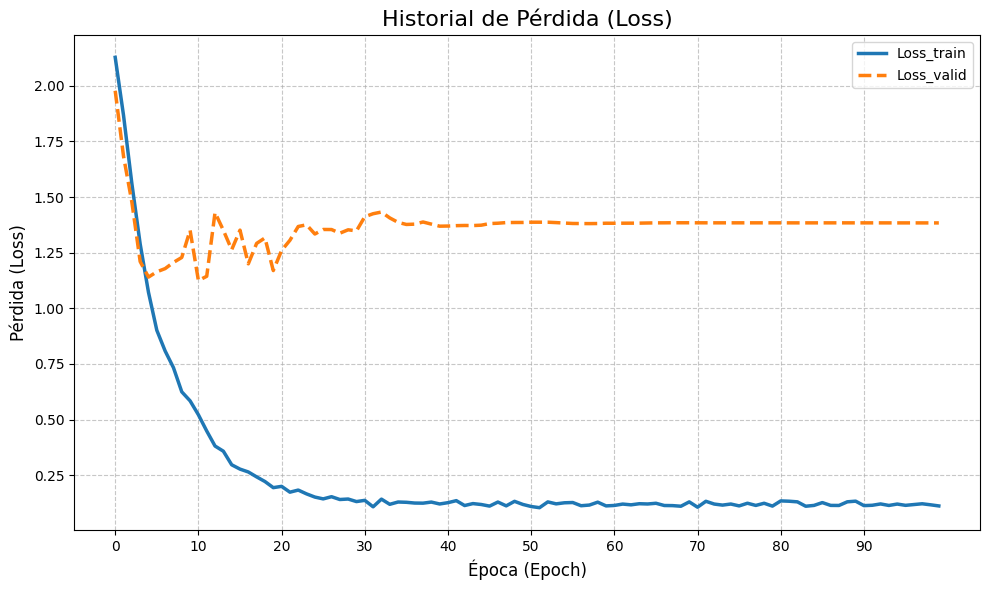

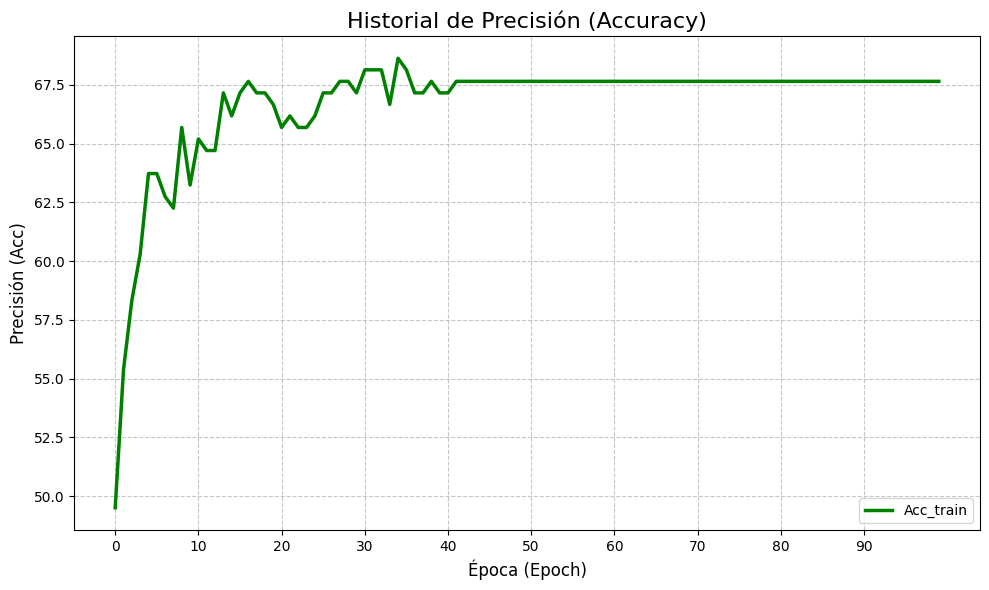

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [22]:
model_sv = NaterawVIT(num_classes=num_class).to(device)
path = "/content/Nat/NetModel.pth"
model_sv.load_state_dict(torch.load(path))


<All keys matched successfully>

In [23]:
loader = valid_loader
labels = list(dm.validdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 1.3515
Test set: Accuracy score: 0.6716
Test set: Macro F1 score: 0.6527

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.8095    0.8095    0.8095        21
       calcium-Ca     0.8929    0.7576    0.8197        33
          iron-Fe     0.9000    0.6923    0.7826        13
     magnesium-Mg     0.2917    0.4375    0.3500        16
     manganese-Mn     0.7692    0.5882    0.6667        17
more-deficiencies     0.2703    0.4762    0.3448        21
       nitrogen-N     0.7000    0.5385    0.6087        13
     phosphorus-P     0.8723    0.8200    0.8454        50
       potasium-K     0.7857    0.5500    0.6471        20

         accuracy                         0.6716       204
        macro avg     0.6991    0.6300    0.6527       204
     weighted avg     0.7354    0.6716    0.6937       204




In [24]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))


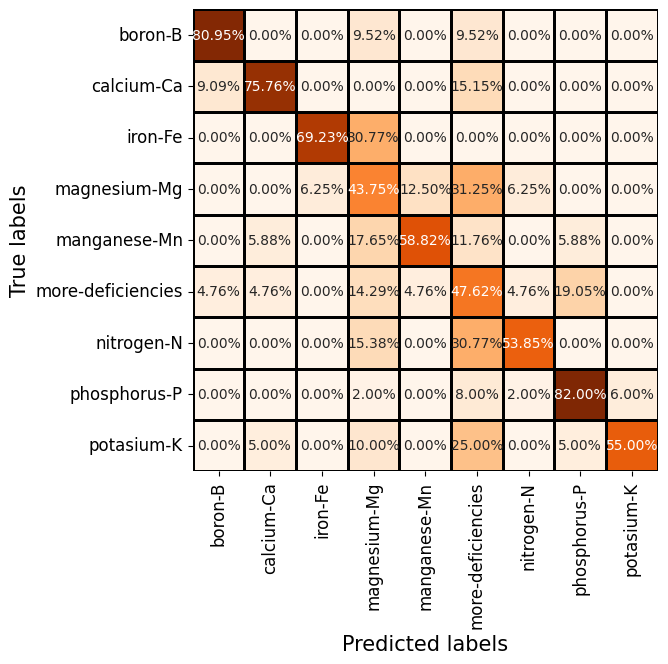

In [26]:
#@title Matriz de confusión en porcentajes
labels =list(dm.validdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [27]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))


                   precision    recall  f1-score   support

          boron-B       0.81      0.81      0.81        21
       calcium-Ca       0.89      0.76      0.82        33
          iron-Fe       0.90      0.69      0.78        13
     magnesium-Mg       0.29      0.44      0.35        16
     manganese-Mn       0.77      0.59      0.67        17
more-deficiencies       0.27      0.48      0.34        21
       nitrogen-N       0.70      0.54      0.61        13
     phosphorus-P       0.87      0.82      0.85        50
       potasium-K       0.79      0.55      0.65        20

         accuracy                           0.67       204
        macro avg       0.70      0.63      0.65       204
     weighted avg       0.74      0.67      0.69       204




# Mircosoft-VIT-beit-patch16-224-pt22k-ft22k



In [ ]:
def saveModel(model):
    dir_Save ="/content/new_Microsoft"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(48110)

In [ ]:
gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch
import torch.nn as nn
from transformers import BeitImageProcessor
from transformers.models.beit.modeling_beit import BeitForImageClassification

class MicrosoftBEiT(nn.Module):
    def __init__(self, num_classes=9, pretrained=True):
        super().__init__()

        self.num_classes = num_classes

        ########
        # Cargar el procesador de imágenes y el modelo preentrenado
        self.processor = BeitImageProcessor.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')
        self.backbone = BeitForImageClassification.from_pretrained('microsoft/beit-base-patch16-224-pt22k-ft22k')

        if pretrained:
            # Congelar los pesos del modelo
            for param in self.backbone.parameters():
                param.requires_grad = False

        # Obtener el número de características de la capa clasificadora
        self.numfeat = self.backbone.classifier.in_features

        # Definir un nuevo bloque de clasificación
        block = nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes)
        )

        # Reemplazar la capa clasificadora del modelo con el nuevo bloque
        self.backbone.classifier = block
        ##########

    def forward(self, x):
        output = self.backbone(x)
        return output.logits

    def get_mean_std(self):
        return (0.5, 0.5, 0.5), (0.5, 0.5, 0.5)


In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
num_class  = 9
lr         = 1e-4
num_epochs  = 100
batch_size = 64
img_size   = 224

model_cnn = MicrosoftBEiT(num_classes=num_class, pretrained=True).to(device)
#criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=4)

preprocessor_config.json:   0%|          | 0.00/276 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/414M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/414M [00:00<?, ?B/s]

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir)
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
#test_loader = dm.test_dataloader()

In [ ]:
# =================================================================
# CÁLCULO DE PESOS
# =================================================================
# 1. Extraemos las etiquetas usando tu variable 'dm'
etiquetas_train = dm.traindata.targets

# 2. Contamos cuántas imágenes hay por clase y aplicamos la fórmula
conteo_clases = torch.bincount(torch.tensor(etiquetas_train))
total_muestras = len(etiquetas_train)
num_clases = len(conteo_clases)

pesos_clases = total_muestras / (num_clases * conteo_clases.float())
pesos_tensor = pesos_clases.to(device).float()


print("="*50)
print(f"⚖️ Pesos matemáticos calculados para las {num_clases} clases:")
print(pesos_tensor)
print("="*50)

# 3 CRITERION CON PESOS INYECTADOS
#criterion = nn.CrossEntropyLoss(weight=pesos_tensor, label_smoothing=0.1).to(device)
criterion = nn.CrossEntropyLoss(weight=pesos_tensor).to(device)

⚖️ Pesos matemáticos calculados para las 9 clases:
tensor([1.1056, 0.6856, 1.7009, 1.4039, 1.3401, 1.0656, 1.7342, 0.4512, 1.1637],
       device='cuda:0')


In [ ]:
# Suponiendo que tu variable se llama 'train_dataset'
print(dm.validdata.class_to_idx.keys())


dict_keys(['boron-B', 'calcium-Ca', 'iron-Fe', 'magnesium-Mg', 'manganese-Mn', 'more-deficiencies', 'nitrogen-N', 'phosphorus-P', 'potasium-K'])


In [ ]:
# Entrenamos el modelo
model, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc=0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 30.0% de capas.
Train Epoch: 1 [0/796 (0%)]	Loss: 2.297
Train Epoch: 1 [640/796 (83%)]	Loss: 1.733
COMPLETED Train Epoch 1: Training Loss is: 1.994 - Validation Loss is: 1.589 - Accuracy is 51.47% - F1 Score is 0.4226
Validation F1-Score increment: 0.0000 ⮕ 0.4226 | Acc: 0.00% ⮕ 51.47% 	 Saving The Model
Train Epoch: 2 [0/796 (0%)]	Loss: 1.794
Train Epoch: 2 [640/796 (83%)]	Loss: 1.180
COMPLETED Train Epoch 2: Training Loss is: 1.344 - Validation Loss is: 1.229 - Accuracy is 66.67% - F1 Score is 0.5946
Validation F1-Score increment: 0.4226 ⮕ 0.5946 | Acc: 51.47% ⮕ 66.67% 	 Saving The Model
Train Epoch: 3 [0/796 (0%)]	Loss: 1.169
Train Epoch: 3 [640/796 (83%)]	Loss: 0.899
COMPLETED Train Epoch 3: Training Loss is: 1.045 - Validation Loss is: 1.156 - Accuracy is 61.76% - F1 Score is 0.5651
Train Epoch: 4 [0/796 (0%)]	Loss: 0.862
Train Epoch: 4 [640/796 (83%)]	Loss: 0.930
COMPLETED Train Epoch 4: Training Loss is: 0.891 - Validat

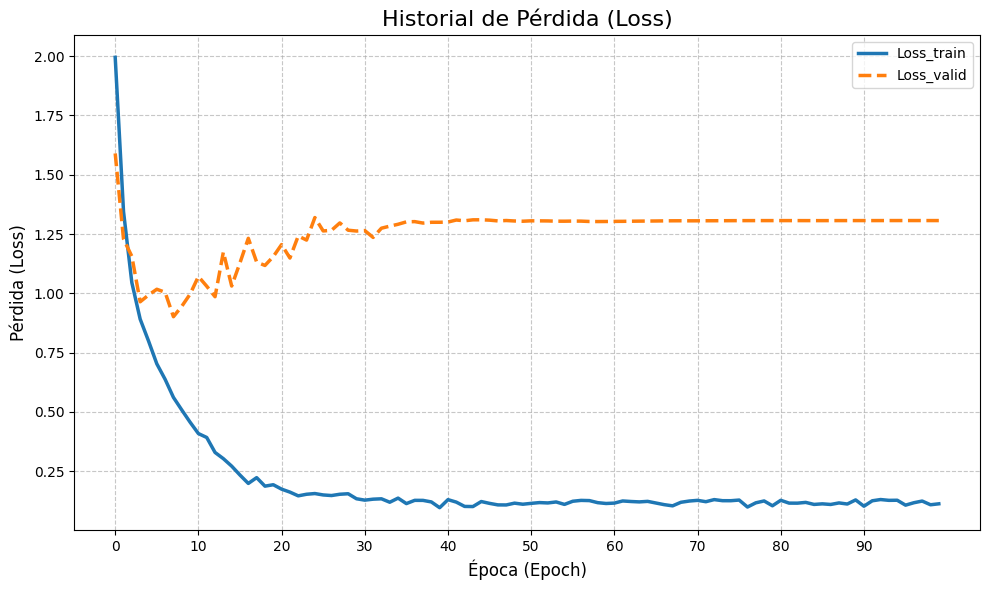

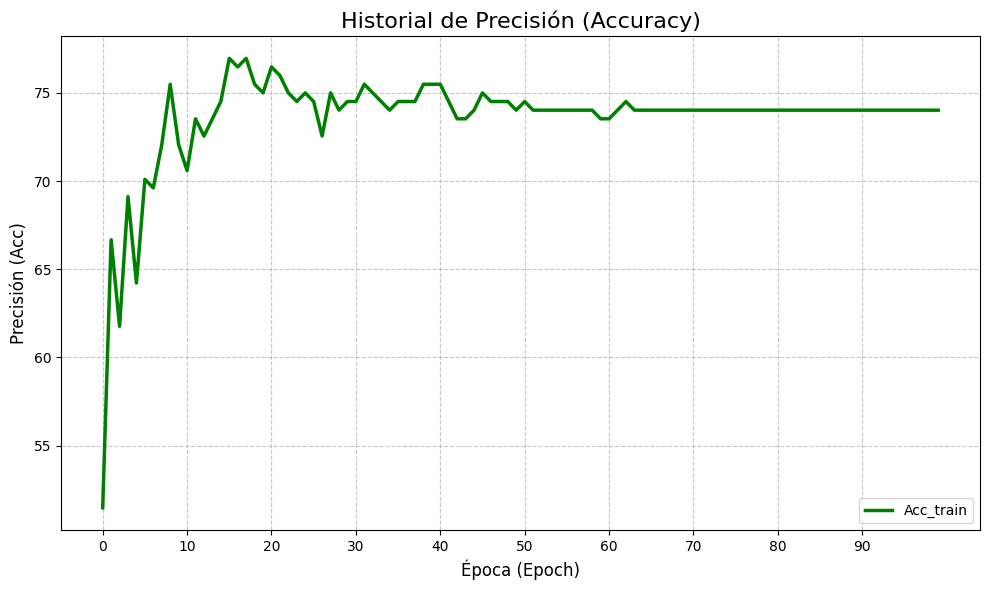

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [ ]:
model_sv = MicrosoftBEiT(num_classes=num_class).to(device)
path = "/content/new_Microsoft/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
loader = valid_loader
labels = list(dm.validdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 1.1318
Test set: Accuracy score: 0.7696
Test set: Macro F1 score: 0.7387

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.8000    0.9524    0.8696        21
       calcium-Ca     0.8788    0.8788    0.8788        33
          iron-Fe     0.9167    0.8462    0.8800        13
     magnesium-Mg     0.3636    0.5000    0.4211        16
     manganese-Mn     0.6923    0.5294    0.6000        17
more-deficiencies     0.5000    0.5238    0.5116        21
       nitrogen-N     0.9091    0.7692    0.8333        13
     phosphorus-P     0.9020    0.9200    0.9109        50
       potasium-K     0.8667    0.6500    0.7429        20

         accuracy                         0.7696       204
        macro avg     0.7588    0.7300    0.7387       204
     weighted avg     0.7846    0.7696    0.7726       204




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

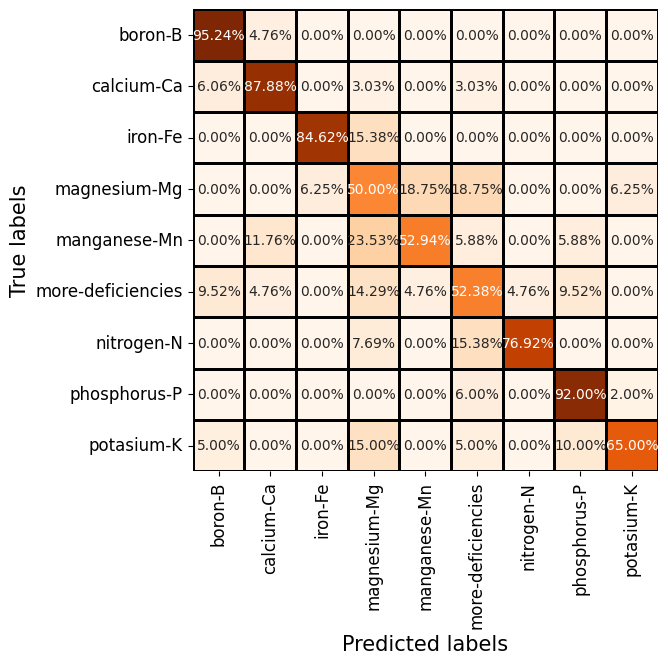

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.validdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.80      0.95      0.87        21
       calcium-Ca       0.88      0.88      0.88        33
          iron-Fe       0.92      0.85      0.88        13
     magnesium-Mg       0.36      0.50      0.42        16
     manganese-Mn       0.69      0.53      0.60        17
more-deficiencies       0.50      0.52      0.51        21
       nitrogen-N       0.91      0.77      0.83        13
     phosphorus-P       0.90      0.92      0.91        50
       potasium-K       0.87      0.65      0.74        20

         accuracy                           0.77       204
        macro avg       0.76      0.73      0.74       204
     weighted avg       0.78      0.77      0.77       204




# MambaVision-L-21K



In [ ]:
def saveModel(model):
    dir_Save ="/content/new_MAMBA"
    os.makedirs(dir_Save, exist_ok=True)
    path = os.path.join(dir_Save, "NetModel.pth")
    torch.save(model.state_dict(), path)

In [ ]:
from transformers import AutoModel
import torch
import torch.nn as nn
from transformers import AutoModelForImageClassification
from timm.data.transforms_factory import create_transform

class MambaVisionCustom(nn.Module):
    def __init__(self, num_classes=10, pretrained=True):
        super().__init__()
        self.num_classes = num_classes

        # 1. Cargar el modelo
        self.backbone = AutoModelForImageClassification.from_pretrained(
            "nvidia/MambaVision-L-21K",
            trust_remote_code=True
        )

        # 2. Congelar pesos
        if pretrained:
            for param in self.backbone.parameters():
                param.requires_grad = False

        # 3. Reemplazar el clasificador de forma directa
        # En tu versión, backbone.model.head es el objeto Linear directamente
        if hasattr(self.backbone, 'model') and hasattr(self.backbone.model, 'head'):
            # Sacamos los rasgos de entrada directamente del Linear
            self.numfeat = self.backbone.model.head.in_features
            # Reemplazamos el Linear por tu Sequential personalizado
            self.backbone.model.head = self._build_custom_head()
        else:
            # Plan de respaldo por si la jerarquía cambia
            self.numfeat = self.backbone.classifier.in_features
            self.backbone.classifier = self._build_custom_head()

    def _build_custom_head(self):
        return nn.Sequential(
            nn.Linear(self.numfeat, 1024),
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.Dropout(0.4),
            nn.Linear(512, self.num_classes)
        )

    def forward(self, x):
        # 1. Obtenemos la salida del modelo de Hugging Face
        outputs = self.backbone(x)

        # 2. Si la salida es un diccionario o un objeto de HF, extraemos los logits
        if isinstance(outputs, dict) and 'logits' in outputs:
            return outputs['logits']
        elif hasattr(outputs, 'logits'):
            return outputs.logits

        # 3. Si por alguna razón ya es un Tensor, lo devolvemos tal cual
        return outputs

    def get_mean_std(self):
        cfg = self.backbone.config
        mean = getattr(cfg, 'mean', (0.485, 0.456, 0.406))
        std = getattr(cfg, 'std', (0.229, 0.224, 0.225))
        return mean, std

In [ ]:
import gc
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(47)

gc.collect()
torch.cuda.empty_cache()

In [ ]:
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
num_class  = 10
lr         = 1e-4
num_epochs  = 50
batch_size = 32
img_size   = 224

model_cnn = MambaVisionCustom(num_classes=num_class, pretrained=True).to(device)
criterion  = nn.CrossEntropyLoss().to(device)
optimizer =  torch.optim.AdamW(model_cnn.parameters(), lr=lr, weight_decay=1e-3)
scheduler = ReduceLROnPlateau(optimizer, mode='max', factor=0.1, patience=3)

In [ ]:
dm = DataModule(model_cnn.get_mean_std(), img_size = img_size, batch_size=batch_size, train_dir = train_dir, valid_dir=valid_dir, test_dir=test_dir )
dm.setup()
train_loader = dm.train_dataloader()
valid_loader = dm.val_dataloader()
test_loader = dm.test_dataloader()

In [ ]:
# Entrenamos el modelo
model, history, lr_history = train(model_cnn, criterion, device, train_loader, valid_loader, optimizer, scheduler, num_epochs, porc=0.3)

Begin training...
APLICANDO FINE TUNING. 
 Descongelando el 40.0% de capas.
Train Epoch: 1 [0/700 (0%)]	Loss: 2.294
COMPLETED Train Epoch 1: Training Loss is: 2.087 - Validation Loss is: 1.676 - Accuracy is 44.67% - F1 Score is 0.3038
Validation F1-Score increment: 0.0000 ⮕ 0.3038 | Acc: 0.00% ⮕ 44.67% 	 Saving The Model
Train Epoch: 2 [0/700 (0%)]	Loss: 1.853
COMPLETED Train Epoch 2: Training Loss is: 1.622 - Validation Loss is: 1.267 - Accuracy is 52.28% - F1 Score is 0.3742
Validation F1-Score increment: 0.3038 ⮕ 0.3742 | Acc: 44.67% ⮕ 52.28% 	 Saving The Model
Train Epoch: 3 [0/700 (0%)]	Loss: 1.530
COMPLETED Train Epoch 3: Training Loss is: 1.224 - Validation Loss is: 1.124 - Accuracy is 59.90% - F1 Score is 0.4497
Validation F1-Score increment: 0.3742 ⮕ 0.4497 | Acc: 52.28% ⮕ 59.90% 	 Saving The Model
Train Epoch: 4 [0/700 (0%)]	Loss: 1.137
COMPLETED Train Epoch 4: Training Loss is: 1.035 - Validation Loss is: 0.946 - Accuracy is 63.96% - F1 Score is 0.5487
Validation F1-Score in

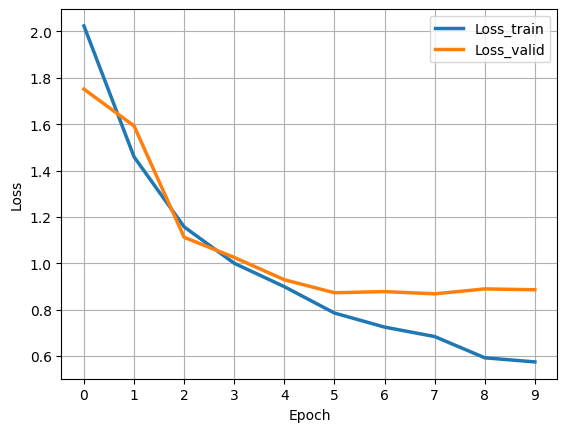

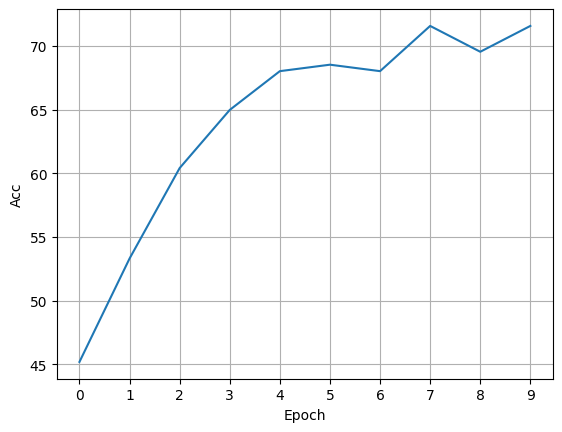

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Simulación de Datos (Reemplaza 'history' con tus datos reales) ---
# history = [ [loss_train, loss_valid, acc_train, acc_valid], ... ]
arr = np.array(history)
num_epochs = arr.shape[0]
epochs_range = np.arange(0, num_epochs) # Creamos el rango de 0 a N
# ----------------------------------------------------------------------

# Definimos cada cuánto queremos ver los números en el eje X para que no se amontonen
# Si son pocas épocas (menos de 20), mostramos todas. Si son muchas, saltamos.
step = max(1, num_epochs // 10)
mis_ticks = np.arange(0, num_epochs, step)

# ==========================================
# GRÁFICO 1: PÉRDIDA (LOSS)
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Pérdida (Loss)', fontsize=16)

plt.plot(epochs_range, arr[:, 0], label='Loss_train', linewidth=2.5)
plt.plot(epochs_range, arr[:, 1], label='Loss_valid', linewidth=2.5, linestyle='--')

plt.ylabel('Pérdida (Loss)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X
plt.xticks(mis_ticks)

plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


# ==========================================
# GRÁFICO 2: PRECISIÓN (ACCURACY) - Sin Acc_valid
# ==========================================
plt.figure(figsize=(10, 6))
plt.title('Historial de Precisión (Accuracy)', fontsize=16)

# Solo ploteamos la columna 2 (Train), ignoramos la 3 (Valid)
plt.plot(epochs_range, arr[:, 2], label='Acc_train', color='green', linewidth=2.5)

plt.ylabel('Precisión (Acc)', fontsize=12)
plt.xlabel('Época (Epoch)', fontsize=12)

# AQUÍ ASEGURAMOS LOS NUMERITOS EN EL EJE X TAMBIÉN
plt.xticks(mis_ticks)

plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Entrenando el Modelo** - Cargando el mejor Modelo

In [ ]:
model_sv = MambaVisionCustom(num_classes=num_class).to(device)
path = "/content/new_MAMBA/NetModel.pth"
model_sv.load_state_dict(torch.load(path))

<All keys matched successfully>

In [ ]:
loader = test_loader
labels = list(dm.testdata.class_to_idx.keys())
y_pred, y_true = test(model_sv, criterion, device, loader, labels)

Iniciando Test...
Test set: Average loss: 0.5771
Test set: Accuracy score: 0.6789
Test set: Macro F1 score: 0.5553

REPORTE DETALLADO POR CLASE:
                   precision    recall  f1-score   support

          boron-B     0.9091    0.9091    0.9091        11
       calcium-Ca     0.8235    0.8235    0.8235        17
          healthy     0.0000    0.0000    0.0000         1
          iron-Fe     0.8000    0.5714    0.6667         7
     magnesium-Mg     0.4167    0.5556    0.4762         9
     manganese-Mn     0.4444    0.4444    0.4444         9
more-deficiencies     0.3333    0.4167    0.3704        12
       nitrogen-N     0.5000    0.1250    0.2000         8
     phosphorus-P     0.8800    0.8800    0.8800        25
       potasium-K     0.6923    0.9000    0.7826        10

         accuracy                         0.6789       109
        macro avg     0.5799    0.5626    0.5553       109
     weighted avg     0.6814    0.6789    0.6681       109




In [ ]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
tot = np.sum(cm, axis=1)
cm_porc = np.divide(cm, np.reshape(tot, (-1,1)))

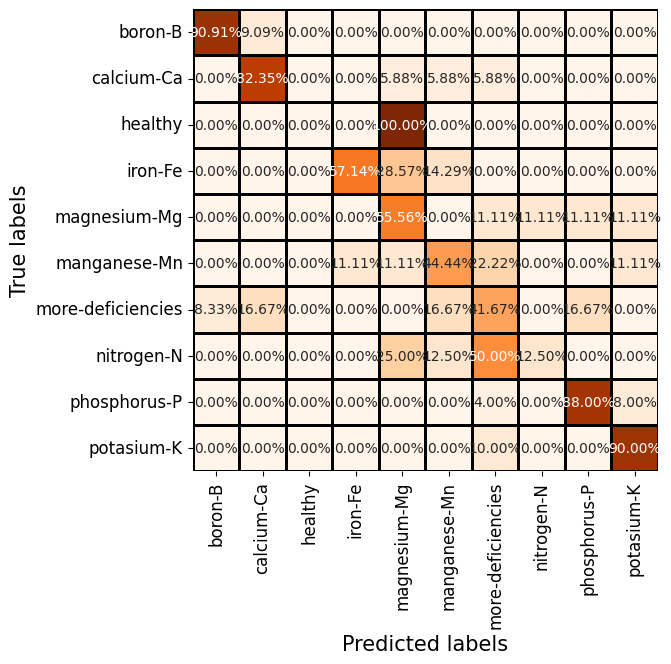

In [ ]:
#@title Matriz de confusión en porcentajes
labels =list(dm.testdata.class_to_idx.keys())
# Calculate confusion matrix
#confusion_matrix = sk_metrics.confusion_matrix(y_true, y_pred)
df_confusion_matrix = pd.DataFrame(cm_porc, index=labels, columns=labels)

# Show confusion matrix
plt.figure(figsize=(6, 6))
sn.heatmap(df_confusion_matrix, annot=True, cbar=False, cmap='Oranges', linewidths=1, linecolor='black', fmt=".2%")
plt.xlabel('Predicted labels', fontsize=15)
plt.xticks(fontsize=12)
plt.ylabel('True labels', fontsize=15)
plt.yticks(fontsize=12);

In [ ]:
report = classification_report(y_true, y_pred, target_names=labels, output_dict=True)
print(classification_report(y_true, y_pred, target_names=labels))

                   precision    recall  f1-score   support

          boron-B       0.91      0.91      0.91        11
       calcium-Ca       0.82      0.82      0.82        17
          healthy       0.00      0.00      0.00         1
          iron-Fe       0.80      0.57      0.67         7
     magnesium-Mg       0.42      0.56      0.48         9
     manganese-Mn       0.44      0.44      0.44         9
more-deficiencies       0.33      0.42      0.37        12
       nitrogen-N       0.50      0.12      0.20         8
     phosphorus-P       0.88      0.88      0.88        25
       potasium-K       0.69      0.90      0.78        10

         accuracy                           0.68       109
        macro avg       0.58      0.56      0.56       109
     weighted avg       0.68      0.68      0.67       109

